# Chapter 3: Step 3 — Fundamentals of Machine Learning

**Course:** Supervised Machine Learning  
**Source:** *Mastering Machine Learning with Python in Six Steps* — Manohar Swamynathan (2019)  
**Book pages:** 145–262 (PDF pages 159–276)

---

## Welcome!

This notebook covers **Chapter 3** — the core ML algorithms chapter. You will learn feature engineering, exploratory data analysis, supervised regression and classification, time-series forecasting, and unsupervised learning with **scikit-learn** and **statsmodels**.

**How to use this notebook:**
1. Run cells **top to bottom** (Shift + Enter).
2. Read each markdown explanation **before** running the code — it tells you *what* the listing teaches and *what to notice* in the output.
3. All book listings (3-1 through 3-56) are included with fixes for modern Python 3.

## Shared Setup

This cell loads the Python libraries used throughout Chapter 3 and points to the course data folder.

**What each import gives you:**
- **NumPy (`np`)** — numeric arrays and math used by every algorithm below.
- **Pandas (`pd`)** — tables (DataFrames) for loading CSV files and preparing features.
- **Matplotlib** — charts for EDA, regression lines, decision boundaries, and diagnostics.
- **scikit-learn** — ready-made ML models (regression, classification, clustering, PCA).
- **statsmodels (`sm`)** — detailed statistical models (OLS regression, GLM, ARIMA time series).

**Helper defined here:**
- `DATA_DIR` — path to the `Data/` folder containing `Grade_Set_1.csv`, `Housing_Modified.csv`, `TS.csv`, etc.
- `plot_decision_regions()` — draws colored regions for 2-D classifiers (SVM and kNN listings).

After running, you should see `Setup complete.` and the resolved path to `Data/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn import datasets, preprocessing, metrics, linear_model, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import sklearn.linear_model as lm

DATA_DIR = Path('Data')

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not installed — OLS/GLM/ARIMA listings will need: pip install statsmodels')


def plot_decision_regions(X, y, classifier, h=0.02):
    """Plot decision regions for a 2-D classifier (used in SVM/kNN listings)."""
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)

print('Setup complete.')
print('DATA_DIR:', DATA_DIR.resolve())


Setup complete.
DATA_DIR: D:\Gurinder Data HardDrive\CIMT College\Course_11_Supervised Machine Learning\Supervised_Machine_Learning\Data


---

## Machine Learning Perspective of Data

Data consists of **objects** (people, plants, transactions) and **attributes** measured on them (age, height, sales). Attributes are also called **variables**.

At a high level:
- **Continuous (quantitative):** numeric values on a wide range (sales amount, temperature).
- **Discrete (qualitative / categorical):** limited set of categories (city, product type).


## Scales of Measurement

Variables are measured on four scales. The scale determines which statistics are meaningful.

### Nominal (categorical)
Categories with no order (color, gender). Use **mode** and proportions.

| Variable | Example values |
|---|---|
| Color | red, green, yellow |
| Gender | female, male |

### Ordinal
Categories with meaningful order but unequal gaps (military rank, clothing size).

### Interval
Equal intervals between values, but no true zero (temperature °C, IQ bands).

### Ratio
Equal intervals **and** a true zero — the most common scale (weight, height, age).

| Scale | Count | Rank | Add/Subtract | Multiply/Divide |
|---|:---:|:---:|:---:|:---:|
| Nominal | ✓ | | | |
| Ordinal | ✓ | ✓ | | |
| Interval | ✓ | ✓ | ✓ | | |
| Ratio | ✓ | ✓ | ✓ | ✓ |


### Figure 3-1 — Logical Flow of Data in ML Model Building

This diagram shows how raw data moves through the ML pipeline: **Raw Data → Information → Insight → Features → Model**. Feature engineering (the step before modeling) is where domain knowledge turns raw columns into predictive signals.

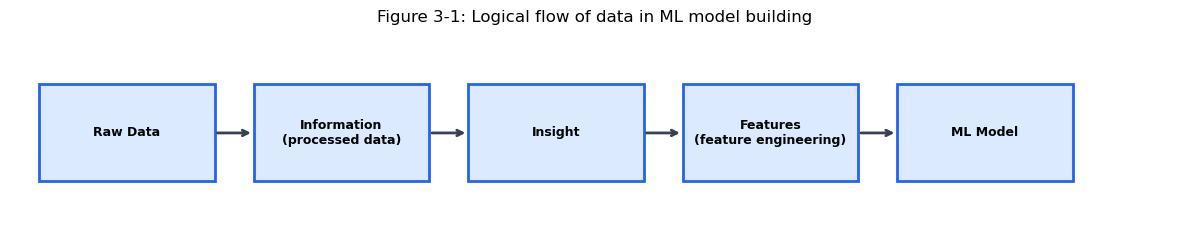

In [2]:
# %matplotlib inline  (enable inline plots in Jupyter)
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 1)
ax.axis('off')
boxes = [
    ('Raw Data', 0.3), ('Information\n(processed data)', 2.5),
    ('Insight', 4.7), ('Features\n(feature engineering)', 6.9),
    ('ML Model', 9.1),
]
for label, x in boxes:
    ax.add_patch(plt.Rectangle((x, 0.25), 1.8, 0.5, fc='#dbeafe', ec='#2563eb', lw=2))
    ax.text(x + 0.9, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')
for x in [2.1, 4.3, 6.5, 8.7]:
    ax.annotate('', xy=(x + 0.4, 0.5), xytext=(x, 0.5),
                arrowprops=dict(arrowstyle='->', color='#374151', lw=2))
ax.set_title('Figure 3-1: Logical flow of data in ML model building', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


---

## Feature Engineering

Prediction quality depends heavily on input features. Feature engineering applies business context to transform raw data into clean, meaningful features for ML algorithms.

### Dealing with Missing Data
Common strategies: **delete** rows, **replace with summary** (mean/median/mode), **random replace**, or **predictive imputation**.

### Handling Categorical Data
- **Dummy variables (one-hot):** k−1 binary columns for k levels.
- **Label encoding:** map categories to integers (use with care for ordered/nominal data).

### Normalizing Data
- **Min-max scaling:** scale to [0, 1].
- **Standardization (z-scores):** zero mean, unit variance — often preferred.


### Listing 3-1. Creating Dummy Variables

**One-hot encoding (dummy variables)** converts text categories into numeric columns that ML algorithms can use. Each category becomes its own True/False column. We use `pd.get_dummies()` with `prefix='A'` so column names stay readable.

**Look for:** three new columns (`A_high`, `A_low`, `A_medium`) — exactly one is `True` per row.

In [3]:
df = pd.DataFrame({'A': ['high', 'medium', 'low'],
                   'B': [10, 20, 30]}, index=[0, 1, 2])
print(df)

df_with_dummies = pd.get_dummies(df, prefix='A', columns=['A'])
print(df_with_dummies)


        A   B
0    high  10
1  medium  20
2     low  30
    B  A_high  A_low  A_medium
0  10    True  False     False
1  20   False  False      True
2  30   False   True     False


### Listing 3-2. Converting the Categorical Variable to Numerics

**Label encoding** maps each category to a single integer (0, 1, 2…). This is simpler than one-hot but implies an order that may not exist (e.g., `high` → 0 and `low` → 1 does *not* mean high < low numerically).

**Compare:** `pd.factorize()` and scikit-learn's `LabelEncoder` — both produce integers, but the mapping order can differ.

In [4]:
df['A_pd_factorized'] = pd.factorize(df['A'])[0]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['A_LabelEncoded'] = le.fit_transform(df['A'])
print(df)


        A   B  A_pd_factorized  A_LabelEncoded
0    high  10                0               0
1  medium  20                1               2
2     low  30                2               1


### Listing 3-3. Normalization and Scaling

**Feature scaling** puts numeric columns on a comparable scale. Min-max scaling squeezes values into [0, 1]; standardization (z-score) centers at 0 with standard deviation 1. Many algorithms (SVM, kNN, regularized regression) work better after scaling.

**Look for:** `MinMaxScaler` and `StandardScaler` output arrays with very different ranges.

In [5]:
from sklearn import preprocessing

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

std_scale = preprocessing.StandardScaler().fit(X)
X_std = std_scale.transform(X)

minmax_scale = preprocessing.MinMaxScaler().fit(X)
X_minmax = minmax_scale.transform(X)

print('Mean before standardization: petal length={:.1f}, petal width={:.1f}'
      .format(X[:, 0].mean(), X[:, 1].mean()))
print('SD before standardization: petal length={:.1f}, petal width={:.1f}'
      .format(X[:, 0].std(), X[:, 1].std()))
print('Mean after standardization: petal length={:.1f}, petal width={:.1f}'
      .format(X_std[:, 0].mean(), X_std[:, 1].mean()))
print('SD after standardization: petal length={:.1f}, petal width={:.1f}'
      .format(X_std[:, 0].std(), X_std[:, 1].std()))
print('\nMin value before min-max scaling: petal length={:.1f}, petal width={:.1f}'
      .format(X[:, 0].min(), X[:, 1].min()))
print('Max value before min-max scaling: petal length={:.1f}, petal width={:.1f}'
      .format(X[:, 0].max(), X[:, 1].max()))
print('Min value after min-max scaling: petal length={:.1f}, petal width={:.1f}'
      .format(X_minmax[:, 0].min(), X_minmax[:, 1].min()))
print('Max value after min-max scaling: petal length={:.1f}, petal width={:.1f}'
      .format(X_minmax[:, 0].max(), X_minmax[:, 1].max()))


Mean before standardization: petal length=3.8, petal width=1.2
SD before standardization: petal length=1.8, petal width=0.8
Mean after standardization: petal length=-0.0, petal width=-0.0
SD after standardization: petal length=1.0, petal width=1.0

Min value before min-max scaling: petal length=1.0, petal width=0.1
Max value before min-max scaling: petal length=6.9, petal width=2.5
Min value after min-max scaling: petal length=0.0, petal width=0.0
Max value after min-max scaling: petal length=1.0, petal width=1.0


### Feature Construction

Creating new features (aggregations, splits, polynomial terms) is often the key differentiator in competitive ML. Summarizing data helps assess quality before modeling.


### Figure 3-2 — Commonly Used Data Summarization Methods

Summary statistics depend on measurement scale: **nominal** data uses counts/mode; **ordinal** adds ranking; **interval** allows addition/subtraction; **ratio** allows all arithmetic including meaningful ratios.

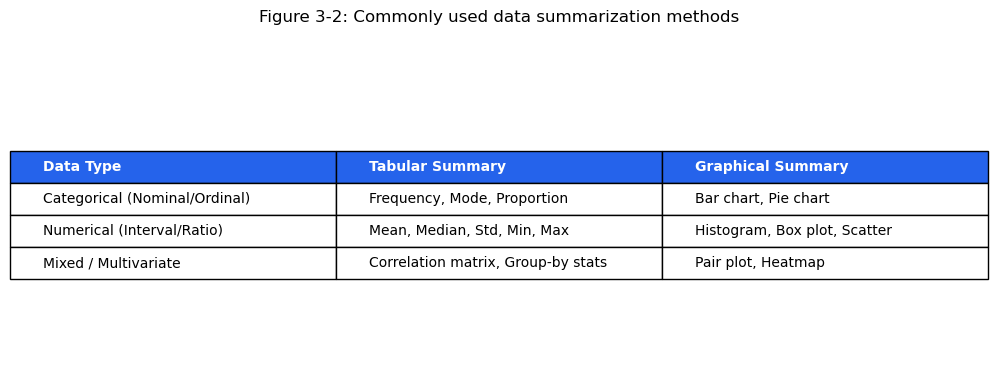

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table_data = [
    ['Data Type', 'Tabular Summary', 'Graphical Summary'],
    ['Categorical (Nominal/Ordinal)', 'Frequency, Mode, Proportion', 'Bar chart, Pie chart'],
    ['Numerical (Interval/Ratio)', 'Mean, Median, Std, Min, Max', 'Histogram, Box plot, Scatter'],
    ['Mixed / Multivariate', 'Correlation matrix, Group-by stats', 'Pair plot, Heatmap'],
]
tbl = ax.table(cellText=table_data, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2563eb')
        cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Figure 3-2: Commonly used data summarization methods', fontsize=12, pad=20)
plt.tight_layout()
plt.show()


---

## Exploratory Data Analysis (EDA)

EDA uses summarization and visualization to understand data quality before modeling.

- **Univariate analysis:** one variable at a time (`describe()`, histograms, box plots).
- **Multivariate analysis:** relationships between variables (group-by means, bar charts).
- **Correlation matrix:** Pearson correlation (−1 to +1).
- **Pair plot:** scatter matrix of all attribute pairs.

We use the famous **Iris** dataset throughout EDA examples.


### Listing 3-4. Univariate Analysis

**Univariate analysis** examines one variable at a time — the first step in EDA. We load the housing dataset and inspect shape, data types, and basic counts.

**Look for:** how many rows/columns exist and which columns are numeric vs. categorical.

In [7]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['species'])
iris_df.species = np.where(iris_df.species == 0.0, 'setosa',
                           np.where(iris_df.species == 1.0, 'versicolor', 'virginica'))
iris_df.columns = iris_df.columns.str.replace(' ', '')
print(iris_df.describe())

print(iris_df['species'].value_counts())


       sepallength(cm)  sepalwidth(cm)  petallength(cm)  petalwidth(cm)
count       150.000000      150.000000       150.000000      150.000000
mean          5.843333        3.057333         3.758000        1.199333
std           0.828066        0.435866         1.765298        0.762238
min           4.300000        2.000000         1.000000        0.100000
25%           5.100000        2.800000         1.600000        0.300000
50%           5.800000        3.000000         4.350000        1.300000
75%           6.400000        3.300000         5.100000        1.800000
max           7.900000        4.400000         6.900000        2.500000
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Listing 3-5. Pandas DataFrame Visualization

Pandas can plot directly from a DataFrame with `.plot()`. Here we visualize the relationship between house **price** and **lot size**.

**Look for:** whether the scatter suggests a linear trend — a hint that linear regression may work.

<Figure size 1500x800 with 0 Axes>

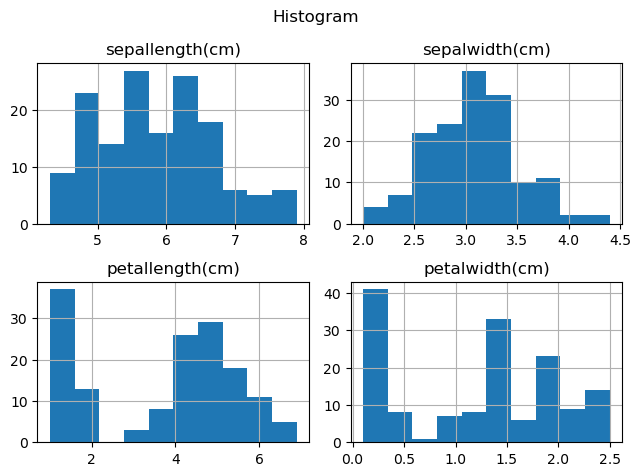

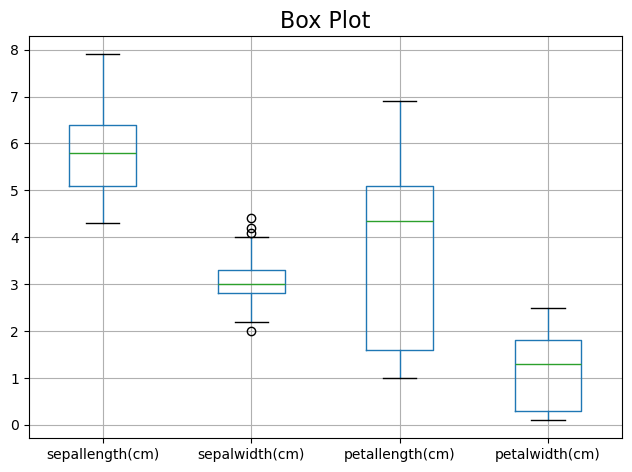

In [8]:
plt.figure(figsize=(15, 8))
iris_df.hist()
plt.suptitle('Histogram', fontsize=12)
plt.tight_layout(pad=1)
plt.show()

iris_df.boxplot()
plt.title('Box Plot', fontsize=16)
plt.tight_layout(pad=1)
plt.show()


### Listing 3-6. A Multivariate Analysis

**Multivariate analysis** looks at several variables together. We compare price against lot size and number of bathrooms on the same chart.

**Look for:** which feature appears more strongly related to price.

            sepallength(cm)  sepalwidth(cm)  petallength(cm)  petalwidth(cm)
species                                                                     
setosa                5.006           3.428            1.462           0.246
versicolor            5.936           2.770            4.260           1.326
virginica             6.588           2.974            5.552           2.026


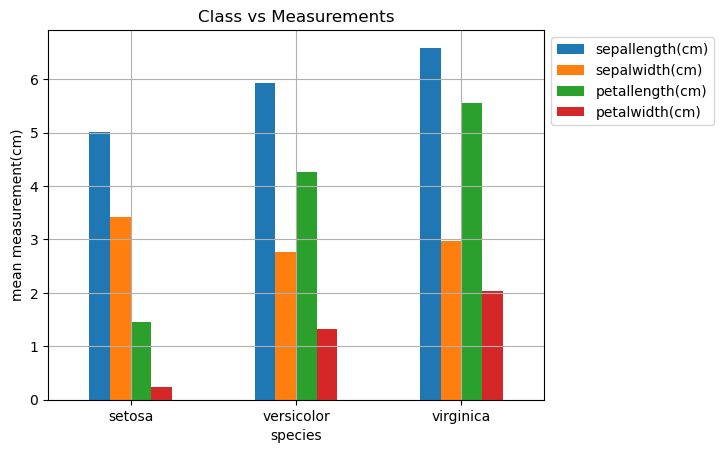

In [9]:
print(iris_df.groupby(by='species').mean())

iris_df.groupby(by='species').mean().plot(kind='bar')
plt.title('Class vs Measurements')
plt.ylabel('mean measurement(cm)')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


### Listing 3-7. Correlation Matrix

A **correlation matrix** measures linear association between every pair of numeric columns (−1 to +1). Values near ±1 mean strong linear relationship; near 0 means weak.

**Look for:** high correlations between `price` and features like `lotsize` or `bathrms`.

                 sepallength(cm)  sepalwidth(cm)  petallength(cm)  \
sepallength(cm)         1.000000       -0.117570         0.871754   
sepalwidth(cm)         -0.117570        1.000000        -0.428440   
petallength(cm)         0.871754       -0.428440         1.000000   
petalwidth(cm)          0.817941       -0.366126         0.962865   

                 petalwidth(cm)  
sepallength(cm)        0.817941  
sepalwidth(cm)        -0.366126  
petallength(cm)        0.962865  
petalwidth(cm)         1.000000  


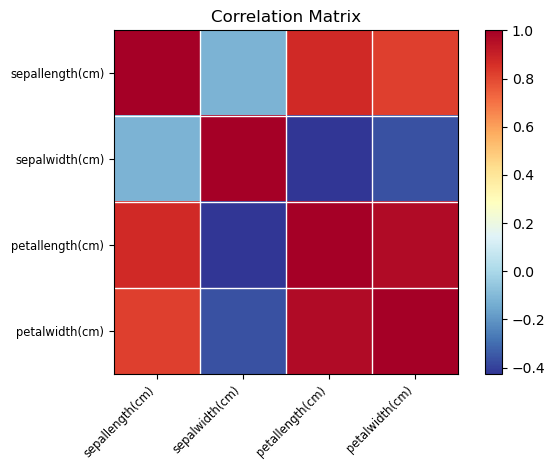

In [10]:
corr = iris_df.select_dtypes(include='number').corr()
print(corr)

if HAS_STATSMODELS:
    sm.graphics.plot_corr(corr, xnames=list(corr.columns))
    plt.show()
else:
    print('Install statsmodels to plot the correlation heatmap.')


### Listing 3-8. Pair Plot

A **pair plot** shows scatter plots for every feature pair plus histograms on the diagonal — a quick multivariate overview.

**Look for:** clusters or linear patterns in the off-diagonal panels.

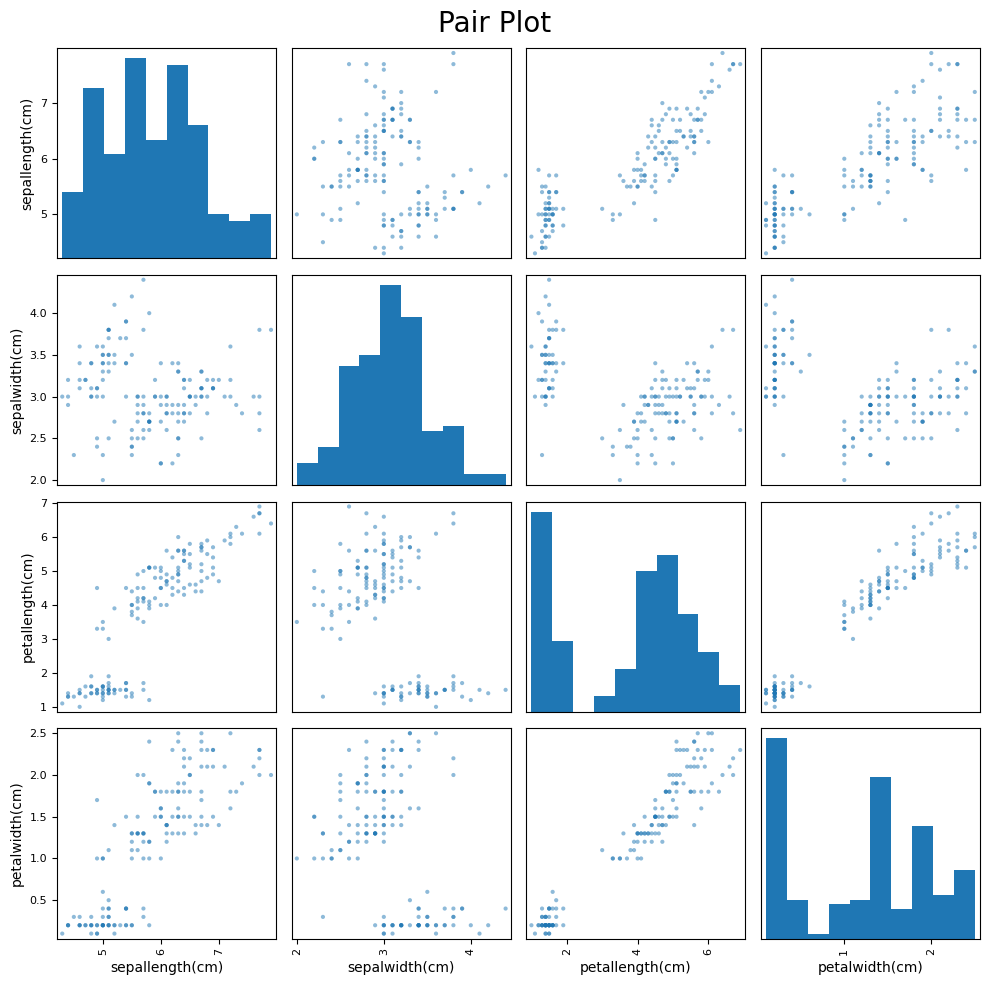

In [11]:
from pandas.plotting import scatter_matrix

scatter_matrix(iris_df.select_dtypes(include='number'), figsize=(10, 10))
plt.suptitle('Pair Plot', fontsize=20)
plt.tight_layout()
plt.show()


### EDA Findings (Iris)

- No missing values.
- Petal length/width are strongly correlated (~96%).
- Setosa is clearly separable from Versicolor/Virginica by petal measurements.


---

## Supervised Learning — Regression

Regression predicts a **continuous** target ("how much?" / "how many?"). We start with simple linear regression: \(Y = mX + c\).

**Key metrics:** R² (goodness of fit), RMSE, MAE.


### Listing 3-9. Students' Score vs. Hours Studied

We start supervised learning with a simple question: *Do more study hours lead to higher test grades?* This listing loads `Grade_Set_1.csv` and plots hours studied against test grade.

**Look for:** a clear upward trend — the classic setup for linear regression.

   Hours_Studied  Test_Grade
0              2          57
1              3          66
2              4          73
3              5          76
4              6          79
5              7          81
6              8          90
7              9          96
8             10         100


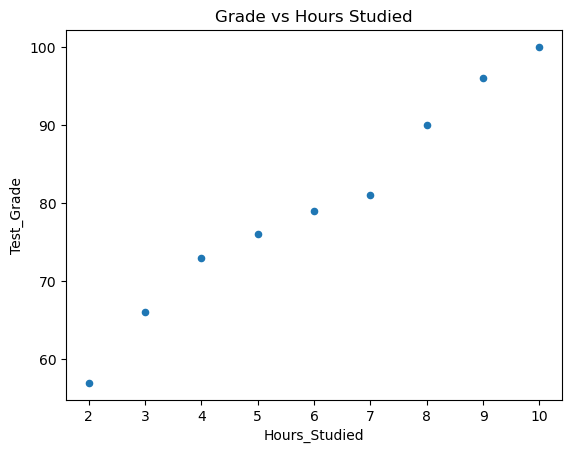

Correlation Matrix:
               Hours_Studied  Test_Grade
Hours_Studied       1.000000    0.987797
Test_Grade          0.987797    1.000000


In [12]:
df = pd.read_csv(str(DATA_DIR / 'Grade_Set_1.csv'))
print(df)

df.plot(kind='scatter', x='Hours_Studied', y='Test_Grade', title='Grade vs Hours Studied')
plt.show()

print('Correlation Matrix:')
print(df.corr())


### Figure 3-5 — Linear Regression Model Components

A linear regression model has two learned parts: **intercept** (baseline prediction when x = 0) and **slope** (how much y changes per unit of x). The line minimizes the sum of squared vertical errors.

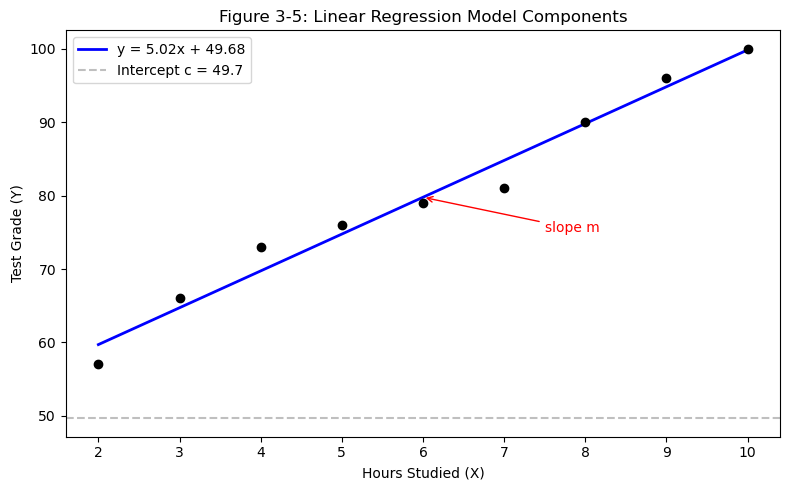

In [13]:
x_plot = df['Hours_Studied'].values
y_plot = df['Test_Grade'].values
m, c = np.polyfit(x_plot, y_plot, 1)
x_line = np.linspace(x_plot.min(), x_plot.max(), 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_plot, y_plot, color='black', zorder=3)
ax.plot(x_line, m * x_line + c, color='blue', linewidth=2, label=f'y = {m:.2f}x + {c:.2f}')
ax.axhline(c, color='gray', linestyle='--', alpha=0.5, label=f'Intercept c = {c:.1f}')
ax.annotate('slope m', xy=(6, m * 6 + c), xytext=(7.5, 75),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
ax.set_xlabel('Hours Studied (X)')
ax.set_ylabel('Test Grade (Y)')
ax.set_title('Figure 3-5: Linear Regression Model Components')
ax.legend()
plt.tight_layout()
plt.show()


### Listing 3-10. Linear Regression

**Simple linear regression** fits a straight line: `grade = intercept + slope × hours`. scikit-learn's `LinearRegression` finds the line that minimizes squared prediction error.

**Look for:** the blue line through the scatter — our first predictive model.

Intercept:  49.67777777777776
Coefficient:  [5.01666667]
Manual prediction: 79.77777779777776
Using predict function: [79.77777778]


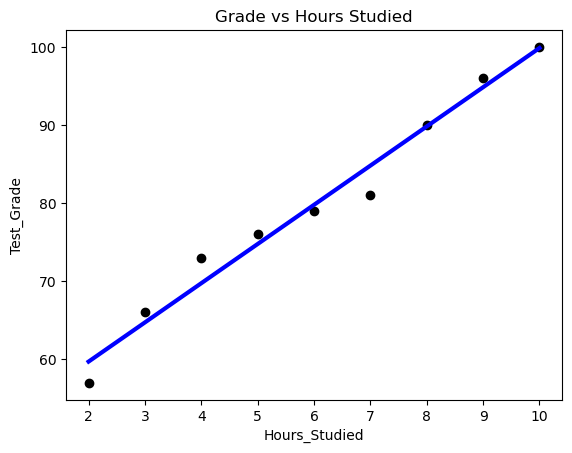

In [14]:
lr = lm.LinearRegression()
x = df['Hours_Studied'].values.reshape(-1, 1)
y = df['Test_Grade'].values

lr.fit(x, y)
print('Intercept: ', lr.intercept_)
print('Coefficient: ', lr.coef_)
print('Manual prediction:', 49.67777777777776 + 5.01666667 * 6)
print('Using predict function:', lr.predict([[6]]))

plt.scatter(x, y, color='black')
plt.plot(x, lr.predict(x), color='blue', linewidth=3)
plt.title('Grade vs Hours Studied')
plt.ylabel('Test_Grade')
plt.xlabel('Hours_Studied')
plt.show()


### Listing 3-11. Linear Regression Model Accuracy Matrices

After fitting, we measure **how good** the model is using three common metrics:
- **R² (R-squared):** fraction of variance explained (1.0 = perfect, 0 = no better than the mean).
- **MAE:** average absolute error in grade points.
- **RMSE:** like MAE but penalizes large errors more.

**Look for:** R² close to 1 and small MAE/RMSE on this simple dataset.

In [15]:
df['Test_Grade_Pred'] = lr.predict(x)
df['SST'] = np.square(df['Test_Grade'] - df['Test_Grade'].mean())
df['SSR'] = np.square(df['Test_Grade_Pred'] - df['Test_Grade'].mean())
print('Sum of SSR:', df['SSR'].sum())
print('Sum of SST:', df['SST'].sum())
print(df)
print('R Squared using manual calculation:', df['SSR'].sum() / df['SST'].sum())
print('R Squared using built-in function:', r2_score(df['Test_Grade'], df['Test_Grade_Pred']))
print('Mean Absolute Error:', mean_absolute_error(df['Test_Grade'], df['Test_Grade_Pred']))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(df['Test_Grade'], df['Test_Grade_Pred'])))


Sum of SSR: 1510.0166666666673
Sum of SST: 1547.5555555555557
   Hours_Studied  Test_Grade  Test_Grade_Pred         SST         SSR
0              2          57        59.711111  518.827160  402.671111
1              3          66        64.727778  189.827160  226.502500
2              4          73        69.744444   45.938272  100.667778
3              5          76        74.761111   14.271605   25.166944
4              6          79        79.777778    0.604938    0.000000
5              7          81        84.794444    1.493827   25.166944
6              8          90        89.811111  104.493827  100.667778
7              9          96        94.827778  263.160494  226.502500
8             10         100        99.844444  408.938272  402.671111
R Squared using manual calculation: 0.9757431074095351
R Squared using built-in function: 0.9757431074095347
Mean Absolute Error: 1.618518518518523
Root Mean Squared Error: 2.0422995995497297


### Listing 3-12. Outlier vs. R-Squared Value

This demo shows how a single **outlier** can distort R². We add one extreme point and refit — the line shifts to chase the outlier.

**Lesson:** always inspect scatter plots and residuals; outliers can mislead linear models.

Intercept:  54.4022988505747
Coefficient:  [4.64367816]
Manual prediction: 82.2643678105747
Using predict function: [82.26436782]


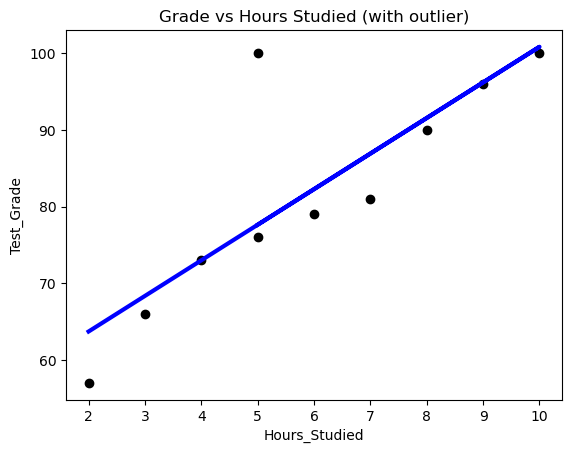

R Squared: 0.6855461390206965
Mean Absolute Error: 4.480459770114941
Root Mean Squared Error: 7.761235830020588


In [16]:
df = pd.read_csv(str(DATA_DIR / 'Grade_Set_1.csv'))
df.loc[9] = np.array([5, 100])
x = df['Hours_Studied'].values.reshape(-1, 1)
y = df['Test_Grade'].values

lr.fit(x, y)
print('Intercept: ', lr.intercept_)
print('Coefficient: ', lr.coef_)
print('Manual prediction:', 54.4022988505747 + 4.64367816 * 6)
print('Using predict function:', lr.predict([[6]]))

plt.scatter(x, y, color='black')
plt.plot(x, lr.predict(x), color='blue', linewidth=3)
plt.title('Grade vs Hours Studied (with outlier)')
plt.ylabel('Test_Grade')
plt.xlabel('Hours_Studied')
plt.show()

df['Test_Grade_Pred'] = lr.predict(x)
print('R Squared:', r2_score(df['Test_Grade'], df['Test_Grade_Pred']))
print('Mean Absolute Error:', mean_absolute_error(df['Test_Grade'], df['Test_Grade_Pred']))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(df['Test_Grade'], df['Test_Grade_Pred'])))


### Polynomial Regression

Higher-degree polynomials fit curves. Watch for **overfitting** when degree is too high.


### Listing 3-13. Polynomial Regression

When data is curved, a straight line fails. **Polynomial regression** adds powers of x (x², x³…) so the model can bend.

**Look for:** the fitted curve tracking the nonlinear pattern better than a line would.

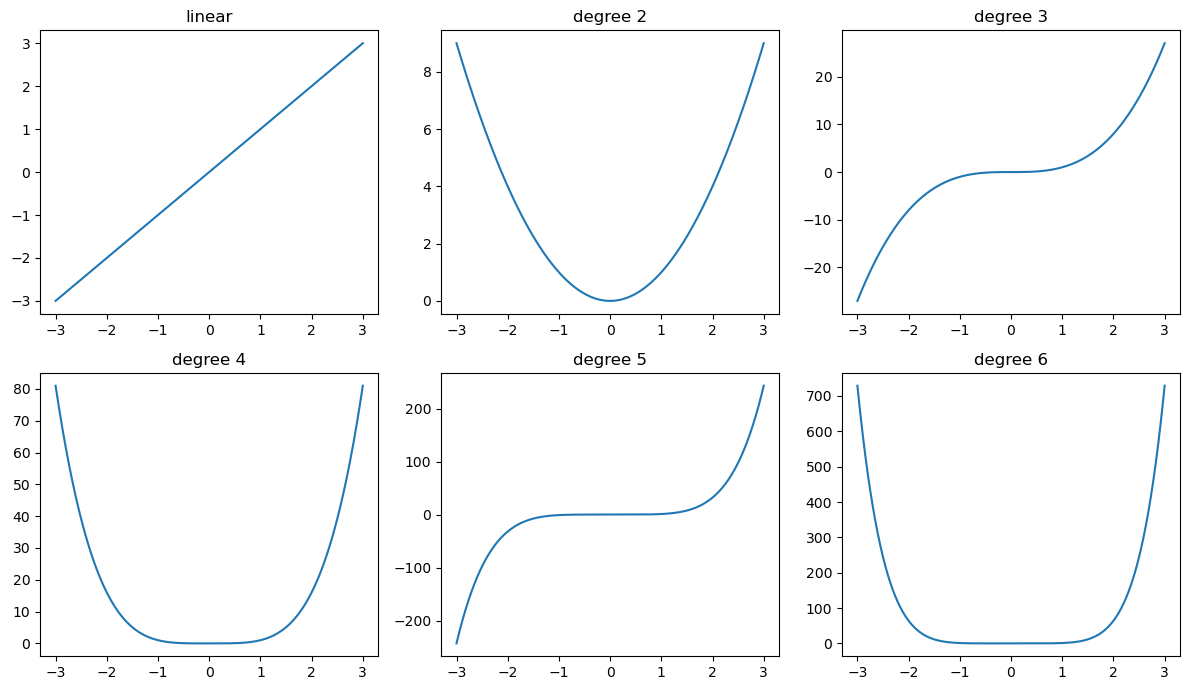

In [17]:
x_poly = np.linspace(-3, 3, 1000)
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(nrows=2, ncols=3, figsize=(12, 7))
ax1.plot(x_poly, x_poly); ax1.set_title('linear')
ax2.plot(x_poly, x_poly ** 2); ax2.set_title('degree 2')
ax3.plot(x_poly, x_poly ** 3); ax3.set_title('degree 3')
ax4.plot(x_poly, x_poly ** 4); ax4.set_title('degree 4')
ax5.plot(x_poly, x_poly ** 5); ax5.set_title('degree 5')
ax6.plot(x_poly, x_poly ** 6); ax6.set_title('degree 6')
plt.tight_layout()
plt.show()


### Listing 3-14. Polynomial Regression Example

A concrete polynomial example on `Grade_Set_2.csv` — a dataset where the relationship is clearly nonlinear.

**Look for:** improved fit compared to a degree-1 (linear) model on the same data.

    Hours_Studied  Test_Grade
0             0.5          20
1             1.0          21
2             2.0          22
3             3.0          23
4             4.0          25
5             5.0          37
6             6.0          48
7             7.0          56
8             8.0          67
9             9.0          76
10           10.0          90
11           11.0          89
12           12.0          90


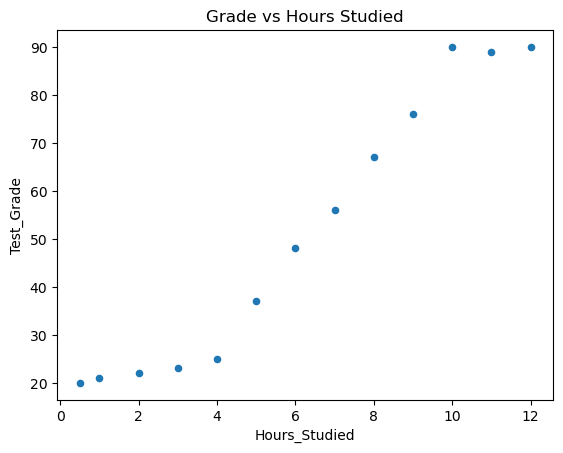

Correlation Matrix:
               Hours_Studied  Test_Grade
Hours_Studied       1.000000    0.974868
Test_Grade          0.974868    1.000000


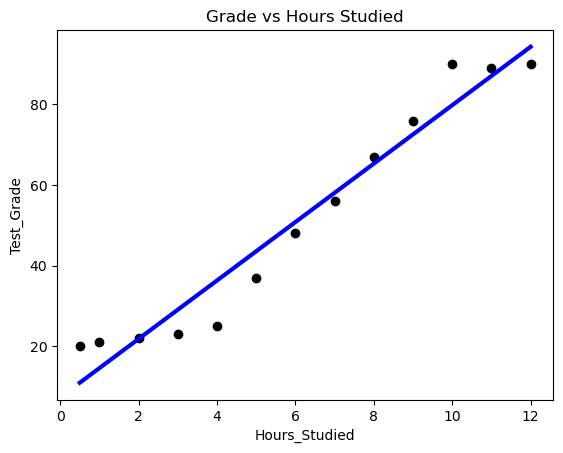

R Squared: 0.9503677766997879


In [18]:
df = pd.read_csv(str(DATA_DIR / 'Grade_Set_2.csv'))
print(df)

df.plot(kind='scatter', x='Hours_Studied', y='Test_Grade', title='Grade vs Hours Studied')
plt.show()

print('Correlation Matrix:')
print(df.corr())

lr = lm.LinearRegression()
x = df['Hours_Studied'].values.reshape(-1, 1)
y = df['Test_Grade']
lr.fit(x, y)

plt.scatter(x, y, color='black')
plt.plot(x, lr.predict(x), color='blue', linewidth=3)
plt.title('Grade vs Hours Studied')
plt.ylabel('Test_Grade')
plt.xlabel('Hours_Studied')
plt.show()

print('R Squared:', r2_score(y, lr.predict(x)))


### Listing 3-15. R-Squared for Different Polynomial Degrees

We try polynomial degrees 1 through 10 and plot R² for each. R² always increases with degree on training data, but very high degrees can **overfit** (memorize noise).

**Look for:** R² jumping toward 1.0 as degree increases — a warning sign on small datasets.

R-squared for degree

 1 = 0.9503677766997879
R-squared for degree 2 = 0.9608726568678714
R-squared for degree 3 = 0.9938323120374665
R-squared for degree 4 = 0.9955000184096712
R-squared for degree 5 = 0.9956204913897356


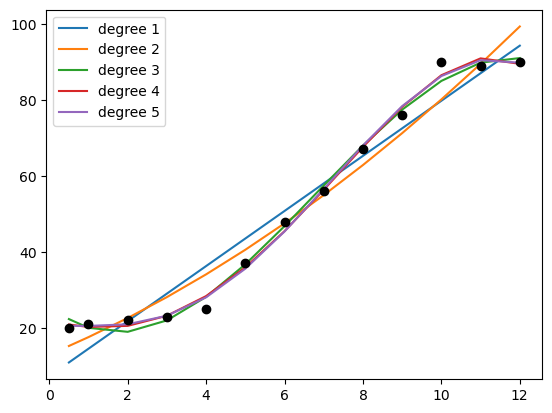

In [19]:
lr = lm.LinearRegression()
x_arr = df['Hours_Studied'].values
y_arr = df['Test_Grade'].values

for deg in [1, 2, 3, 4, 5]:
    lr.fit(np.vander(x_arr, deg + 1), y_arr)
    y_lr = lr.predict(np.vander(x_arr, deg + 1))
    plt.plot(x_arr, y_lr, label='degree ' + str(deg))
    plt.legend(loc=2)
    print('R-squared for degree', deg, '=', r2_score(y_arr, y_lr))
plt.plot(x_arr, y_arr, 'ok')
plt.show()


### Listing 3-16. Scikit-learn Polynomial Features

scikit-learn's `PolynomialFeatures` + `Pipeline` builds polynomial terms automatically and keeps the workflow clean. A pipeline chains preprocessing and the regression model in one object.

**Look for:** the same polynomial fit with less manual column creation.

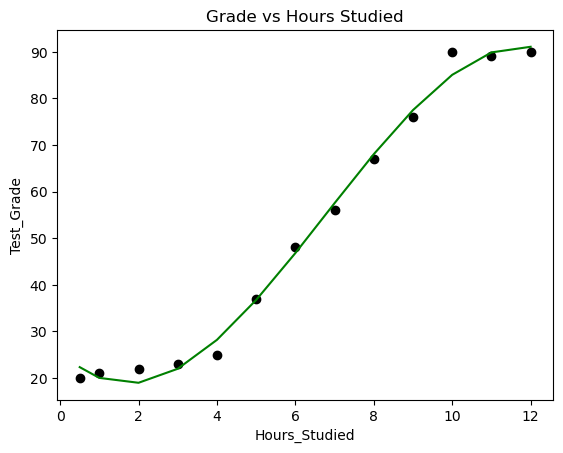

R Squared using built-in function: 0.9938323120374665


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x = df['Hours_Studied'].values.reshape(-1, 1)
y = df['Test_Grade']
degree = 3
model = make_pipeline(PolynomialFeatures(degree), lm.LinearRegression())
model.fit(x, y)

plt.scatter(x, y, color='black')
plt.plot(x, model.predict(x), color='green')
plt.title('Grade vs Hours Studied')
plt.ylabel('Test_Grade')
plt.xlabel('Hours_Studied')
plt.show()

print('R Squared using built-in function:', r2_score(y, model.predict(x)))


---

## Multivariate Regression

Real problems have multiple predictors: \(y = m_1 x_1 + m_2 x_2 + \ldots\). **statsmodels** OLS provides rich diagnostics; **scikit-learn** is efficient for production.

Watch for **multicollinearity** — use **VIF** (variance inflation factor; rule of thumb: VIF > 10).


### Listing 3-17. Multicollinearity and VIF

**Multicollinearity** means two or more input features are highly correlated with each other. It inflates coefficient variance and makes individual feature effects hard to interpret.

**VIF (Variance Inflation Factor):** values above ~5–10 suggest problematic collinearity.

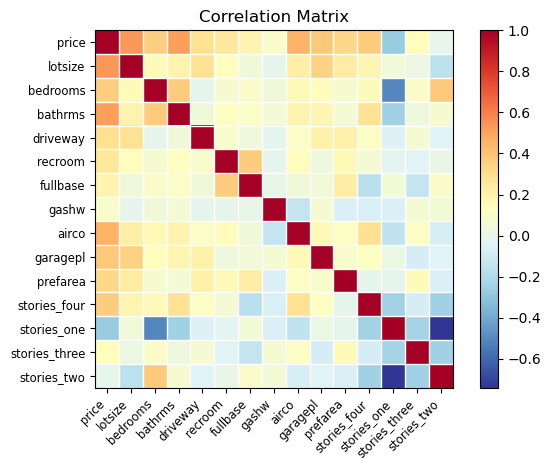

In [21]:
df = pd.read_csv(str(DATA_DIR / 'Housing_Modified.csv'))

def _yes_no_to_int(series):
    return (series.astype(str).str.lower() == 'yes').astype(float)

for col in ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']:
    df[col] = _yes_no_to_int(df[col])

df_stories = pd.get_dummies(df['stories'], prefix='stories')
df = pd.concat([df.drop(columns=['stories']), df_stories], axis=1)

corr = df.corr(numeric_only=True)
if HAS_STATSMODELS:
    sm.graphics.plot_corr(corr, xnames=list(corr.columns))
    plt.show()
else:
    print('Install statsmodels for correlation plot.')


### Listing 3-18. Remove Multicollinearity

We iteratively drop the feature with the highest VIF until all remaining VIFs are below a threshold (here, 10). This is a practical way to reduce multicollinearity before OLS regression.

**Look for:** which dummy-encoded `stories_*` columns get removed first.

In [22]:
if not HAS_STATSMODELS:
    raise ImportError('Listing 3-18 requires statsmodels: pip install statsmodels')
from statsmodels.stats.outliers_influence import variance_inflation_factor

independent_variables = ['lotsize', 'bedrooms', 'bathrms', 'driveway', 'recroom',
                         'fullbase', 'gashw', 'airco', 'garagepl', 'prefarea',
                         'stories_one', 'stories_two', 'stories_three']
independent_variables = [c for c in independent_variables if c in df.columns]
X = df[independent_variables].astype(float)
y = df['price'].astype(float)
thresh = 10
for _ in np.arange(0, len(independent_variables)):
    vif = [variance_inflation_factor(X[independent_variables].values, ix)
           for ix in range(X[independent_variables].shape[1])]
    maxloc = vif.index(max(vif))
    if max(vif) > thresh:
        print('vif:', vif)
        print("dropping '" + independent_variables[maxloc] + "' at index:", maxloc)
        del independent_variables[maxloc]
    else:
        break
print('Final variables:', independent_variables)


vif: [8.958098087844336, 18.469878559519948, 8.984672347290864, 7.08857854209188, 1.477015281503392, 2.0133202364723854, 1.1034879198994194, 1.7567462065609025, 1.9826489313438442, 1.5332946465459893, 3.965752674786861, 5.511702408354892, 1.7700402770614867]
dropping 'bedrooms' at index: 1
Final variables: ['lotsize', 'bathrms', 'driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl', 'prefarea', 'stories_one', 'stories_two', 'stories_three']


### Listing 3-19. Build the Multivariate Linear Regression Model

**Multivariate OLS** (Ordinary Least Squares) predicts price from many features at once using statsmodels. Unlike sklearn, statsmodels prints a full statistical summary: coefficients, p-values, confidence intervals.

**Look for:** `summary()` table — significant features have small p-values (typically < 0.05).

In [23]:
independent_variables = ['lotsize', 'bathrms', 'driveway', 'fullbase', 'gashw', 'airco',
                         'garagepl', 'prefarea', 'stories_one', 'stories_three']
independent_variables = [c for c in independent_variables if c in df.columns]
X = df[independent_variables].astype(float)
y = df['price'].astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=1)

ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)
print('Train MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('Train RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print('Test MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Test RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))


                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.954
Model:                            OLS   Adj. R-squared (uncentered):              0.953
Method:                 Least Squares   F-statistic:                              876.8
Date:                Fri, 05 Jun 2026   Prob (F-statistic):                   5.12e-277
Time:                        19:08:12   Log-Likelihood:                         -4829.2
No. Observations:                 436   AIC:                                      9678.
Df Residuals:                     426   BIC:                                      9719.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

### Regression Diagnostics

Check **outliers** (leverage/residual plots), **homoscedasticity** (constant error variance), and **linearity** (partial regression plots).

### Regularization

**Ridge (L2)** shrinks coefficients toward zero. **Lasso (L1)** can zero-out weak features.


### Listing 3-20. Plot the Normalized Residual vs. Leverage

**Leverage vs. residual** plot for regression diagnostics. Points with high leverage (unusual x-values) and large residuals are influential outliers.

**Look for:** points far from the bulk of the cloud — candidates for investigation.

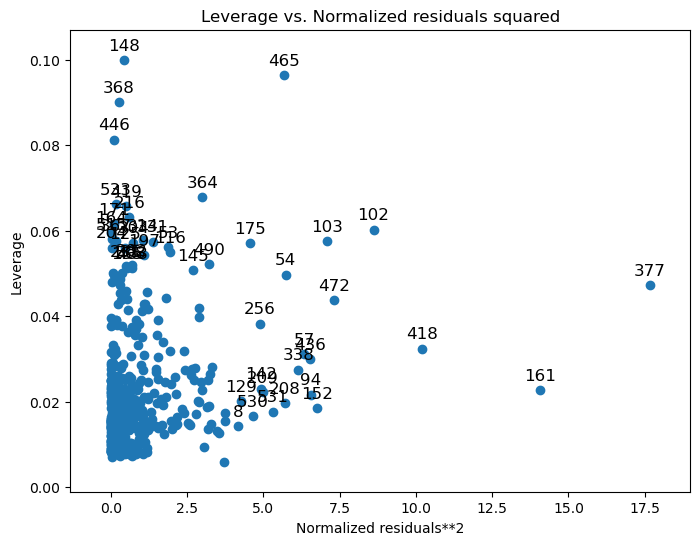

In [24]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2

fig, ax = plt.subplots(figsize=(8, 6))
plot_leverage_resid2(ols_model, ax=ax)
plt.show()


### Listing 3-21. Find Outliers

statsmodels' **outlier test** flags observations whose residuals are unusually large after adjusting for multiple testing (Bonferroni).

**Look for:** rows printed where `bonf(p) < 0.05` — potential bad data points.

In [25]:
test = ols_model.outlier_test()
print('Bad data points (bonf(p) < 0.05):')
print(test[test['bonf(p)'] < 0.05])


Bad data points (bonf(p) < 0.05):
     student_resid   unadj_p   bonf(p)
377       4.387449  0.000014  0.006315


### Listing 3-22. Homoscedasticity Test

**Homoscedasticity** means residuals have constant spread across all fitted values. The residual plot should look like a random cloud; the histogram checks if errors are roughly normal.

**Look for:** funnel shapes in the residual plot (heteroscedasticity) or heavy skew in the histogram.

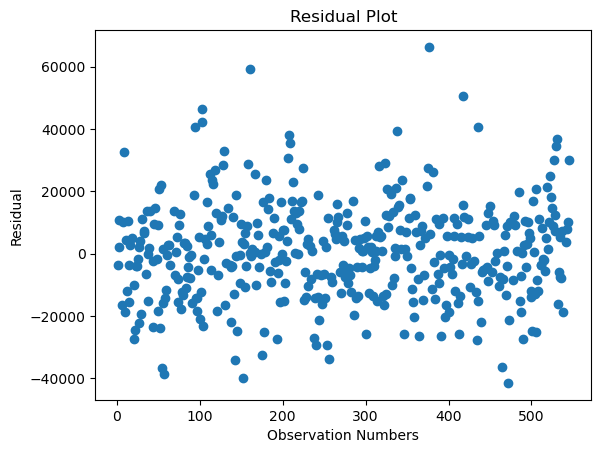

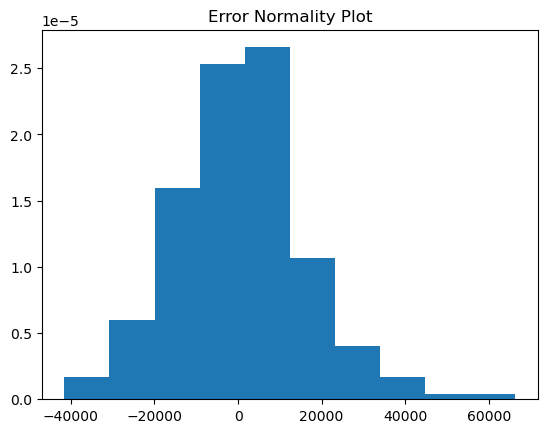

In [26]:
plt.plot(ols_model.resid, 'o')
plt.title('Residual Plot')
plt.ylabel('Residual')
plt.xlabel('Observation Numbers')
plt.show()

plt.hist(ols_model.resid, density=True)
plt.title('Error Normality Plot')
plt.show()


### Listing 3-23. Linearity Check

**Partial regression plots** show the relationship between each feature and the target after removing the effect of other features.

**Look for:** whether each relationship still looks approximately linear.

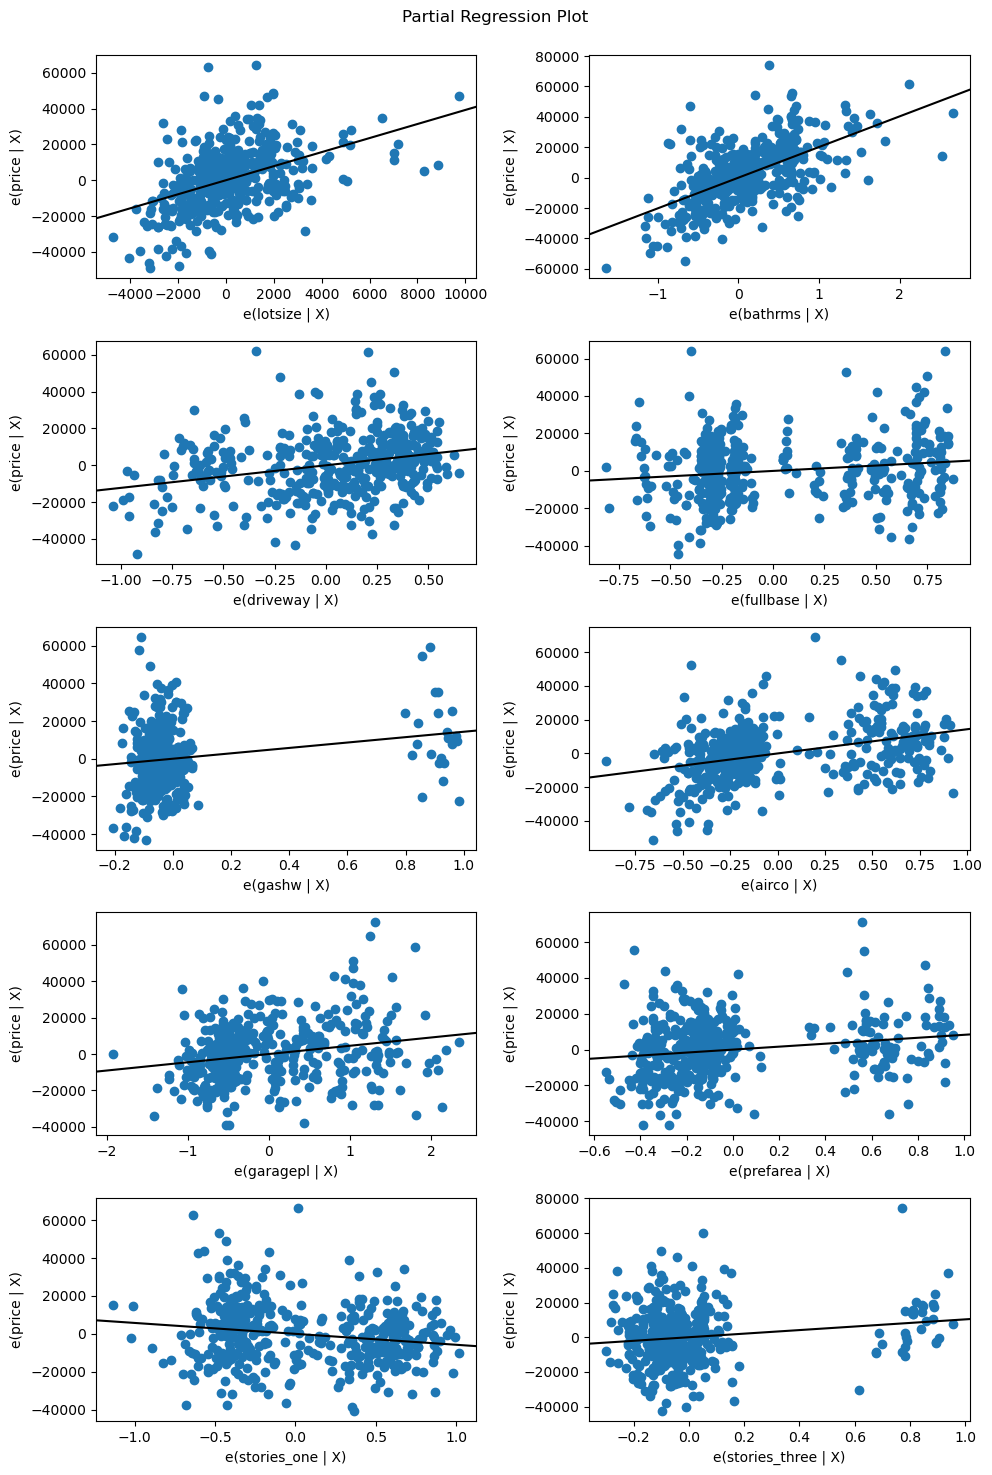

In [27]:
fig = plt.figure(figsize=(10, 15))
sm.graphics.plot_partregress_grid(ols_model, fig=fig)
plt.show()


### Listing 3-24. Regularization

**Regularization** adds a penalty for large coefficients to fight overfitting when there are many features. - **Ridge (L2):** shrinks all coefficients toward zero.
- **Lasso (L1):** can force some coefficients to exactly zero (feature selection).

**Look for:** Ridge and Lasso test RMSE compared to an unregularized model with 48 polynomial terms.

In [28]:
df_reg = pd.read_csv(str(DATA_DIR / 'Grade_Set_2.csv'))
df_reg.columns = ['x', 'y']
for i in range(2, 50):
    df_reg['x_%d' % i] = df_reg['x'] ** i
independent_variables = list(df_reg.columns)
independent_variables.remove('y')
X = df_reg[independent_variables]
y = df_reg['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=1)

lr_ridge = linear_model.Ridge(alpha=0.001)
lr_ridge.fit(X_train, y_train)
y_train_pred = lr_ridge.predict(X_train)
y_test_pred = lr_ridge.predict(X_test)
print('------ Ridge Regression ------')
print('Train MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('Train RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print('Test MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Test RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('Ridge Coef (first 5):', lr_ridge.coef_[:5])

lr_lasso = linear_model.Lasso(alpha=0.001)
lr_lasso.fit(X_train, y_train)
y_train_pred = lr_lasso.predict(X_train)
y_test_pred = lr_lasso.predict(X_test)
print('----- LASSO Regression -----')
print('Train MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('Train RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print('Test MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Test RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('LASSO Coef (first 5):', lr_lasso.coef_[:5])


------ Ridge Regression ------
Train MAE: 12.775326528414379
Train RMSE: 16.72063936357992
Test MAE: 22.397943556789926
Test RMSE: 22.432642089791898
Ridge Coef (first 5): [1.01446487e-88 1.27690319e-87 1.41113660e-86 1.49319913e-85
 1.54589299e-84]
----- LASSO Regression -----
Train MAE: 0.8423742988874547
Train RMSE: 1.2191291855606026
Test MAE: 4.323647594043444
Test RMSE: 4.872324349696682
LASSO Coef (first 5): [1.29948409e+00 3.92103580e-01 1.75369422e-02 7.79647589e-04
 3.02339084e-05]


### Listing 3-25. Nonlinear Regression

**Nonlinear curve fitting** with `scipy.optimize.curve_fit` fits a custom formula (here, a sine/cosine mix) to data. Useful when you have a domain-specific equation rather than polynomials.

**Look for:** the fitted curve matching the oscillating pattern.

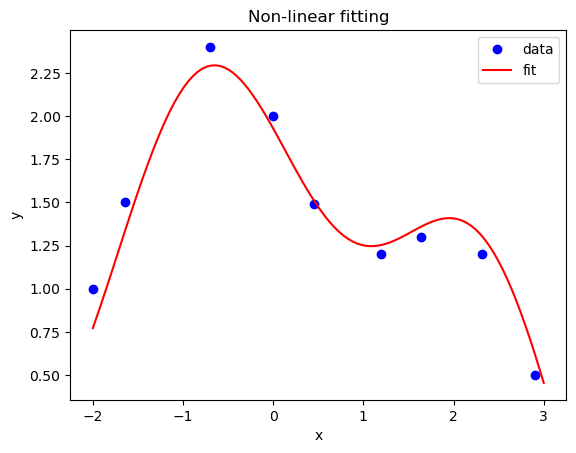

In [29]:
from scipy.optimize import curve_fit

x_nl = np.array([-2, -1.64, -0.7, 0, 0.45, 1.2, 1.64, 2.32, 2.9])
y_nl = np.array([1.0, 1.5, 2.4, 2, 1.49, 1.2, 1.3, 1.2, 0.5])

def func(x, p1, p2):
    return p1 * np.sin(p2 * x) + p2 * np.cos(p1 * x)

popt, pcov = curve_fit(func, x_nl, y_nl, p0=(1.0, 0.2))
p1, p2 = popt
curvex = np.linspace(-2, 3, 100)
curvey = func(curvex, p1, p2)

plt.plot(x_nl, y_nl, 'bo ')
plt.plot(curvex, curvey, 'r')
plt.title('Non-linear fitting')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(['data', 'fit'], loc='best')
plt.show()


---

## Supervised Learning — Classification

Classification predicts a **discrete class** (pass/fail, churn yes/no). Linear regression fails for binary outcomes — use **logistic regression** with the **sigmoid** function.

Evaluate with **confusion matrix**, **ROC/AUC**, and watch for **overfitting** via regularization (C parameter).


### Listing 3-26. Logistic Regression

Linear regression fails for **classification** (predicting 0/1 pass-fail). We try it anyway on `Grade_Set_1_Classification.csv` to show why — predictions fall between 0 and 1 and the line is a poor fit.

**Look for:** low R² and predicted values outside [0, 1].

   Hours_Studied  Result
0              2       0
1              3       0
2              4       0
3              5       1
4              6       1
5              7       1
6              8       1
7              9       1
8             10       1


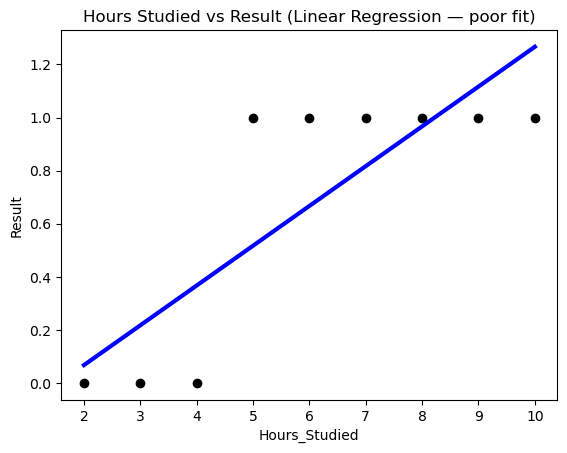

R Squared: 0.675
Mean Absolute Error: 0.2296296296296296
Root Mean Squared Error: 0.26874192494328497


In [30]:
df_cls = pd.read_csv(str(DATA_DIR / 'Grade_Set_1_Classification.csv'))
print(df_cls)

x_cls = df_cls['Hours_Studied'].values.reshape(-1, 1)
y_cls = df_cls['Result']

lr_cls = lm.LinearRegression()
lr_cls.fit(x_cls, y_cls)

plt.scatter(x_cls, y_cls, color='black')
plt.plot(x_cls, lr_cls.predict(x_cls), color='blue', linewidth=3)
plt.title('Hours Studied vs Result (Linear Regression — poor fit)')
plt.ylabel('Result')
plt.xlabel('Hours_Studied')
plt.show()

df_cls['Result_Pred'] = lr_cls.predict(x_cls)
print('R Squared:', r2_score(df_cls['Result'], df_cls['Result_Pred']))
print('Mean Absolute Error:', mean_absolute_error(df_cls['Result'], df_cls['Result_Pred']))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(df_cls['Result'], df_cls['Result_Pred'])))


### Listing 3-27. Plot Sigmoid Function

The **sigmoid function** squashes any real number into (0, 1) — the building block of logistic regression. At z = 0 the output is 0.5; large positive z → 1, large negative z → 0.

**Look for:** the S-shaped curve centered at 0.5.

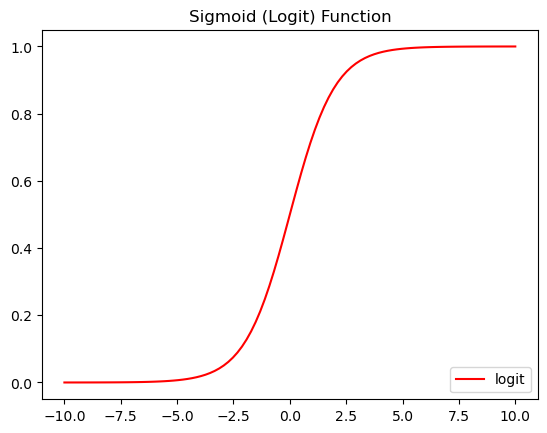

In [31]:
x_sig = np.linspace(-10, 10, 100)
y_sig = 1.0 / (1.0 + np.exp(-x_sig))
plt.plot(x_sig, y_sig, 'r-', label='logit')
plt.legend(loc='lower right')
plt.title('Sigmoid (Logit) Function')
plt.show()


### Listing 3-28. Logistic Regression Using Scikit-learn

**Logistic regression** predicts class probabilities with the sigmoid applied to a linear combination of features. We fit on hours studied and classify pass (1) vs. fail (0).

**Look for:** predicted probabilities and the decision boundary near the middle of the study-hour range.

Accuracy score: 1.0
Predicted probability: [0.05368062 0.15313611 0.36565616 0.64757973 0.85417548 0.94916743
 0.98347736 0.99475738 0.99834945]
Predicted Class: [0 0 0 1 1 1 1 1 1]


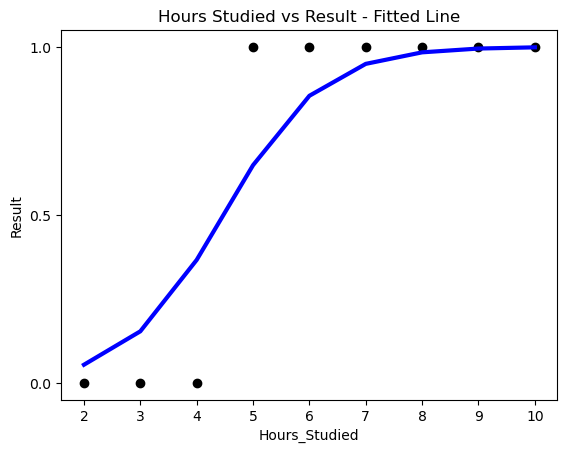

In [32]:
from sklearn.linear_model import LogisticRegression

df_cls['intercept'] = 1
independent_variables = ['Hours_Studied', 'intercept']
x_cls = df_cls[independent_variables]
y_cls = df_cls['Result']

model = LogisticRegression(max_iter=1000)
model = model.fit(x_cls, y_cls)
print('Accuracy score:', model.score(x_cls, y_cls))
print('Predicted probability:', model.predict_proba(x_cls)[:, 1])
print('Predicted Class:', model.predict(x_cls))

plt.scatter(df_cls['Hours_Studied'], y_cls, color='black')
plt.yticks([0.0, 0.5, 1.0])
plt.plot(df_cls['Hours_Studied'], model.predict_proba(x_cls)[:, 1], color='blue', linewidth=3)
plt.title('Hours Studied vs Result - Fitted Line')
plt.ylabel('Result')
plt.xlabel('Hours_Studied')
plt.show()


### Listing 3-29. Confusion Matrix

A **confusion matrix** compares predicted vs. actual classes:
| | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 | TN | FP |
| Actual 1 | FN | TP |

**Look for:** zeros on the off-diagonal — perfect classification on this tiny dataset.

In [33]:
print('Accuracy:', metrics.accuracy_score(y_cls, model.predict(x_cls)))
print('AUC:', metrics.roc_auc_score(y_cls, model.predict_proba(x_cls)[:, 1]))
print('Confusion matrix:', metrics.confusion_matrix(y_cls, model.predict(x_cls)))
print('Classification report:', metrics.classification_report(y_cls, model.predict(x_cls)))


Accuracy: 1.0
AUC: 1.0
Confusion matrix: [[3 0]
 [0 6]]
Classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



### Listing 3-30. Area Under the Curve

**ROC curve** plots True Positive Rate vs. False Positive Rate at every classification threshold. **AUC** (Area Under Curve) summarizes overall performance — 1.0 is perfect, 0.5 is random guessing.

**Look for:** AUC near 1.0 on this separable dataset.

ROC AUC: 1.00


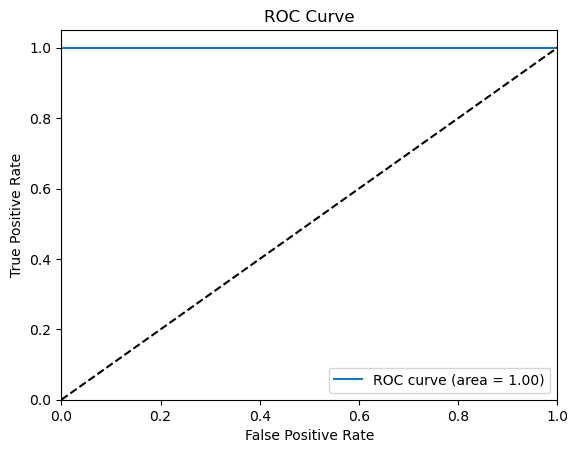

In [34]:
fpr, tpr, _ = metrics.roc_curve(y_cls, model.predict_proba(x_cls)[:, 1])
roc_auc = metrics.auc(fpr, tpr)
print('ROC AUC: %0.2f' % roc_auc)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


### Listing 3-31. Controling Complexity for Fitting a Line

On nonlinearly separable data (`LR_NonLinear.csv`), we map raw features into **polynomial space** so logistic regression can draw curved boundaries. The regularization parameter **C** controls complexity (small C = more penalty = simpler boundary).

**Look for:** how the red decision contour changes from smooth (C=0.01) to wiggly (C=10000).

C = 1 (default), Accuracy: 1.0
C = 10, Accuracy: 1.0
C = 100, Accuracy: 1.0
C = 1000, Accuracy: 1.0


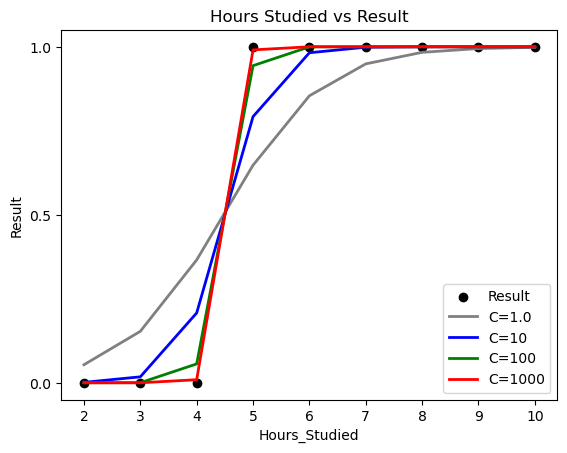

In [35]:
model = LogisticRegression(max_iter=1000).fit(x_cls, y_cls)
print('C = 1 (default), Accuracy:', metrics.accuracy_score(y_cls, model.predict(x_cls)))

model1 = LogisticRegression(C=10, max_iter=1000).fit(x_cls, y_cls)
print('C = 10, Accuracy:', metrics.accuracy_score(y_cls, model1.predict(x_cls)))

model2 = LogisticRegression(C=100, max_iter=1000).fit(x_cls, y_cls)
print('C = 100, Accuracy:', metrics.accuracy_score(y_cls, model2.predict(x_cls)))

model3 = LogisticRegression(C=1000, max_iter=1000).fit(x_cls, y_cls)
print('C = 1000, Accuracy:', metrics.accuracy_score(y_cls, model3.predict(x_cls)))

plt.scatter(df_cls['Hours_Studied'], y_cls, color='black', label='Result')
plt.yticks([0.0, 0.5, 1.0])
plt.plot(df_cls['Hours_Studied'], model.predict_proba(x_cls)[:, 1], color='gray', linewidth=2, label='C=1.0')
plt.plot(df_cls['Hours_Studied'], model1.predict_proba(x_cls)[:, 1], color='blue', linewidth=2, label='C=10')
plt.plot(df_cls['Hours_Studied'], model2.predict_proba(x_cls)[:, 1], color='green', linewidth=2, label='C=100')
plt.plot(df_cls['Hours_Studied'], model3.predict_proba(x_cls)[:, 1], color='red', linewidth=2, label='C=1000')
plt.legend(loc='lower right')
plt.title('Hours Studied vs Result')
plt.ylabel('Result')
plt.xlabel('Hours_Studied')
plt.show()


### Listing 3-32. Underfitting, Right-Fitting, and Overfitting

Three plots illustrate the **bias–variance tradeoff**:
- **Underfitting:** model too simple (high bias).
- **Right-fitting:** captures the pattern without memorizing noise.
- **Overfitting:** model too complex (high variance).

**Look for:** which polynomial degree gives the best balance on held-out logic.

Train Accuracy for C=0.01: 0.6909090909090909
Test Accuracy for C=0.01: 0.704225352112676


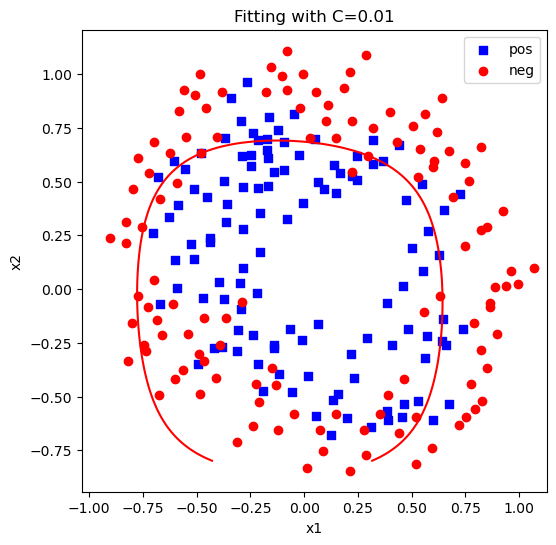

Train Accuracy for C=1: 0.8363636363636363
Test Accuracy for C=1: 0.8028169014084507


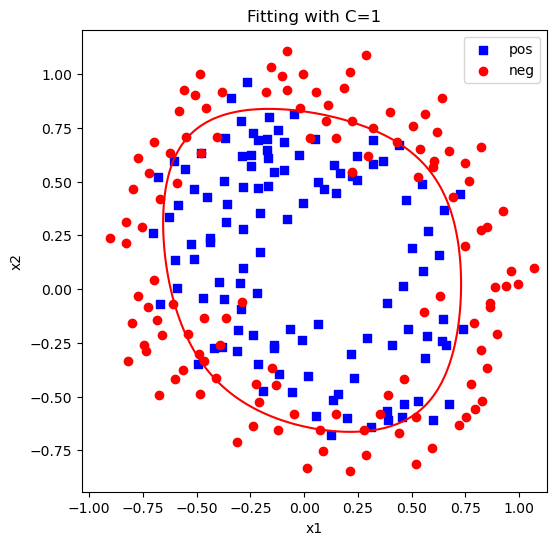

Train Accuracy for C=10000: 0.8606060606060606
Test Accuracy for C=10000: 0.7887323943661971


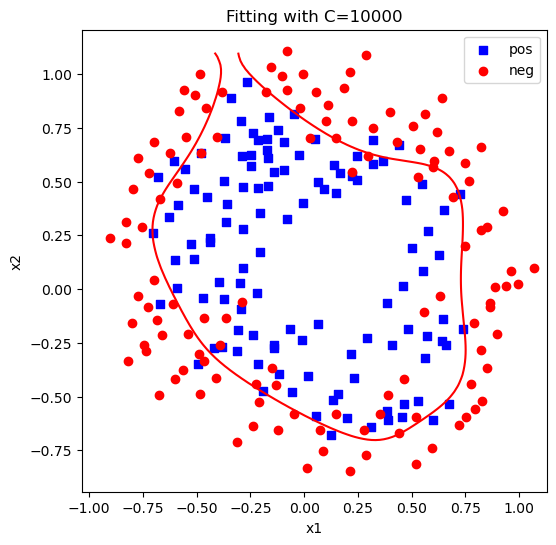

In [36]:
data = pd.read_csv(str(DATA_DIR / 'LR_NonLinear.csv'))
pos = data['class'] == 1
neg = data['class'] == 0
x1 = data['x1']
x2 = data['x2']

def draw_plot():
    plt.figure(figsize=(6, 6))
    plt.scatter(x1[pos], x2[pos], c='b', marker='s', label='pos')
    plt.scatter(x1[neg], x2[neg], c='r', marker='o', label='neg')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.gca().set_aspect('equal', 'datalim')
    plt.legend()

order_no = 6

def map_features(variable_1, variable_2, order=order_no):
    assert order >= 1
    def iter_feats():
        for i in range(1, order + 1):
            for j in range(i + 1):
                yield np.power(variable_1, i - j) * np.power(variable_2, j)
    return np.vstack(list(iter_feats()))

out = map_features(data['x1'], data['x2'], order=order_no)
X_poly = out.transpose()
y_poly = data['class']
X_train, X_test, y_train, y_test = train_test_split(X_poly, y_poly, test_size=0.3, random_state=0)

def draw_boundary(classifier):
    dim = np.linspace(-0.8, 1.1, 100)
    dx, dy = np.meshgrid(dim, dim)
    v = map_features(dx.flatten(), dy.flatten(), order=order_no)
    z = (np.dot(classifier.coef_, v) + classifier.intercept_).reshape(100, 100)
    plt.contour(dx, dy, z, levels=[0], colors=['r'])

for c_val, title in [(0.01, 'C=0.01'), (1, 'C=1'), (10000, 'C=10000')]:
    clf = LogisticRegression(C=c_val, max_iter=1000).fit(X_train, y_train)
    print('Train Accuracy for', title + ':', clf.score(X_train, y_train))
    print('Test Accuracy for', title + ':', clf.score(X_test, y_test))
    draw_plot()
    plt.title('Fitting with ' + title)
    draw_boundary(clf)
    plt.legend()
    plt.show()


### Multiclass Logistic Regression

Logistic regression extends to **multiclass** problems (e.g., three Iris species). Normalize features, split train/test, and evaluate with accuracy and confusion matrix.


### Figure 3-13 — Supervised Learning Process Flow

The supervised learning workflow: **load data → preprocess → split train/test → train model → evaluate on test set → deploy**. Every classification listing from 3-33 onward follows this pattern.

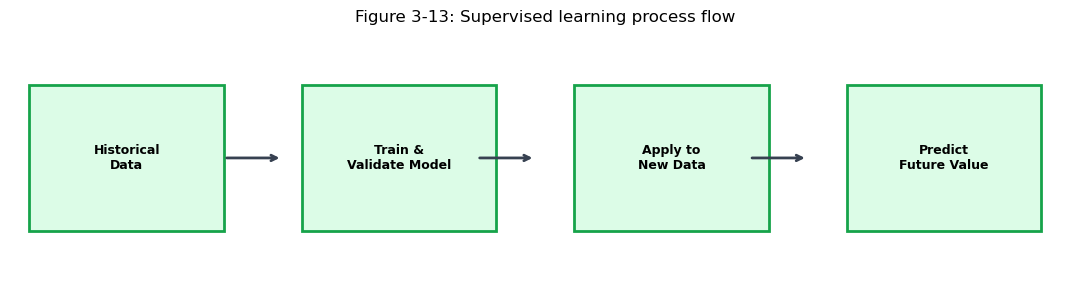

In [37]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 11)
ax.set_ylim(0, 1)
ax.axis('off')
steps = [
    ('Historical\nData', 0.2), ('Train &\nValidate Model', 3.0),
    ('Apply to\nNew Data', 5.8), ('Predict\nFuture Value', 8.6),
]
for label, x in steps:
    ax.add_patch(plt.Rectangle((x, 0.2), 2.0, 0.6, fc='#dcfce7', ec='#16a34a', lw=2))
    ax.text(x + 1.0, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')
for x in [2.2, 4.8, 7.6]:
    ax.annotate('', xy=(x + 0.6, 0.5), xytext=(x, 0.5),
                arrowprops=dict(arrowstyle='->', color='#374151', lw=2))
ax.set_title('Figure 3-13: Supervised learning process flow', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


### Listing 3-33. Load Data

Start of the **full supervised workflow** on the Pima Indians diabetes dataset (from sklearn). We load features and the binary `Outcome` target (diabetes yes/no).

**Look for:** 768 rows, 8 features, and class balance in `Outcome`.

In [38]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
print('Class labels:', np.unique(y))


Class labels: [0 1 2]


### Listing 3-34. Normalize Data

Neural networks and distance-based models need **normalized** inputs. We scale all 8 features to zero mean and unit variance with `StandardScaler`.

**Look for:** transformed arrays with mean ≈ 0 and std ≈ 1 per column.

In [39]:
sc = preprocessing.StandardScaler()
sc.fit(X)
X = sc.transform(X)


### Listing 3-35. Split Data into Train and Test

**Train/test split** reserves 30% of data for unbiased evaluation. The model never sees test labels during training — this simulates real-world prediction on new patients.

**Look for:** `X_train`/`X_test` shapes — typically ~537 train and ~231 test rows.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


### Listing 3-36. Logistic Regression Model Training and Evaluation

We train **logistic regression** on the diabetes data and evaluate with accuracy, confusion matrix, and classification report (precision, recall, F1 per class).

**Look for:** accuracy around 0.75–0.80 — reasonable but not perfect; recall for diabetic patients matters clinically.

In [41]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty='l1', C=10, solver='liblinear', random_state=0, max_iter=1000)
lr.fit(X_train, y_train)

print('Train - Accuracy:', metrics.accuracy_score(y_train, lr.predict(X_train)))
print('Train - Confusion matrix:', metrics.confusion_matrix(y_train, lr.predict(X_train)))
print('Train - classification report:', metrics.classification_report(y_train, lr.predict(X_train)))
print('Test - Accuracy:', metrics.accuracy_score(y_test, lr.predict(X_test)))
print('Test - Confusion matrix:', metrics.confusion_matrix(y_test, lr.predict(X_test)))
print('Test - classification report:', metrics.classification_report(y_test, lr.predict(X_test)))


Train - Accuracy: 0.9809523809523809
Train - Confusion matrix: [[34  0  0]
 [ 0 30  2]
 [ 0  0 39]]
Train - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      0.94      0.97        32
           2       0.95      1.00      0.97        39

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test - Accuracy: 0.9777777777777777
Test - Confusion matrix: [[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Test - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98 

### Generalized Linear Models (GLM)

GLM unifies linear, logistic, Poisson, and other models through a **family** and **link** function.


### Listing 3-37. Generalized Linear Model

**GLM (Generalized Linear Model)** in statsmodels fits the same logistic model but with rich statistical output — coefficients, z-stats, p-values, and confidence intervals for each feature.

**Look for:** which features have p-values below 0.05 (statistically significant predictors).

In [42]:
df_glm = pd.read_csv(str(DATA_DIR / 'Grade_Set_1.csv'))
print('####### Linear Regression Model ########')
lr_glm = lm.LinearRegression()
x_glm = df_glm['Hours_Studied'].values.reshape(-1, 1)
y_glm = df_glm['Test_Grade'].values
lr_glm.fit(x_glm, y_glm)
print('Intercept:', lr_glm.intercept_)
print('Coefficient:', lr_glm.coef_)

print('\n####### Generalized Linear Model ########')
if HAS_STATSMODELS:
    x_glm_sm = sm.add_constant(x_glm, prepend=False)
    glm_model = sm.GLM(y_glm, x_glm_sm, family=sm.families.Gaussian())
    glm_model = glm_model.fit()
    print(glm_model.summary())
else:
    print('statsmodels not available — install with: pip install statsmodels')


####### Linear Regression Model ########
Intercept: 49.67777777777776
Coefficient: [5.01666667]

####### Generalized Linear Model ########
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                    9
Model:                            GLM   Df Residuals:                        7
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          5.3627
Method:                          IRLS   Log-Likelihood:                -19.197
Date:                Fri, 05 Jun 2026   Deviance:                       37.539
Time:                        19:08:21   Pearson chi2:                     37.5
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025     

---

## Decision Trees

Decision trees split data on attribute tests (Gini or entropy). They are easy to interpret and provide explicit decision rules.


### Listing 3-38. Decision Tree Model

A **decision tree** splits data on feature thresholds in a tree structure. Easy to interpret ('if Glucose > 127 then…') but can overfit without depth limits.

**Look for:** training accuracy often higher than test accuracy — a sign of overfitting.

In [43]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

sc = preprocessing.StandardScaler()
X = sc.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X_train, y_train)

print('Train - Accuracy:', metrics.accuracy_score(y_train, clf.predict(X_train)))
print('Train - Confusion matrix:', metrics.confusion_matrix(y_train, clf.predict(X_train)))
print('Train - classification report:', metrics.classification_report(y_train, clf.predict(X_train)))
print('Test - Accuracy:', metrics.accuracy_score(y_test, clf.predict(X_test)))
print('Test - Confusion matrix:', metrics.confusion_matrix(y_test, clf.predict(X_test)))
print('Test - classification report:', metrics.classification_report(y_test, clf.predict(X_test)))

try:
    from io import StringIO
    import pydot
    out_data = StringIO()
    tree.export_graphviz(clf, out_file=out_data,
                         feature_names=iris.feature_names,
                         class_names=clf.classes_.astype(int).astype(str),
                         filled=True, rounded=True,
                         special_characters=True)
    graph = pydot.graph_from_dot_data(out_data.getvalue())
    graph[0].write_pdf('iris_tree.pdf')
    print('Decision tree exported to iris_tree.pdf (requires Graphviz installed).')
except (ImportError, OSError, Exception) as exc:
    print('Skipping Graphviz export — install graphviz and pydot to visualize the tree.')
    print('Error:', exc)


Train - Accuracy: 1.0
Train - Confusion matrix: [[34  0  0]
 [ 0 32  0]
 [ 0  0 39]]
Train - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        32
           2       1.00      1.00      1.00        39

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test - Accuracy: 0.9777777777777777
Test - Confusion matrix: [[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Test - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98      

## Support Vector Machines (SVM)

SVM finds the optimal hyperplane that maximizes the margin between classes.


### Listing 3-39. Support Vector Machine (SVM) Model

**Support Vector Machine (SVM)** finds the boundary that maximizes the margin between classes. With `kernel='rbf'`, it handles nonlinear boundaries.

**Look for:** test accuracy compared to logistic regression — SVM can win on some datasets.

In [44]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

sc = preprocessing.StandardScaler()
X = sc.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

from sklearn.svm import SVC
clf = SVC(kernel='linear', C=1.0, random_state=0)
clf.fit(X_train, y_train)

print('Train - Accuracy:', metrics.accuracy_score(y_train, clf.predict(X_train)))
print('Train - Confusion matrix:', metrics.confusion_matrix(y_train, clf.predict(X_train)))
print('Train - classification report:', metrics.classification_report(y_train, clf.predict(X_train)))
print('Test - Accuracy:', metrics.accuracy_score(y_test, clf.predict(X_test)))
print('Test - Confusion matrix:', metrics.confusion_matrix(y_test, clf.predict(X_test)))
print('Test - classification report:', metrics.classification_report(y_test, clf.predict(X_test)))


Train - Accuracy: 0.9523809523809523
Train - Confusion matrix: [[34  0  0]
 [ 0 30  2]
 [ 0  3 36]]
Train - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       0.91      0.94      0.92        32
           2       0.95      0.92      0.94        39

    accuracy                           0.95       105
   macro avg       0.95      0.95      0.95       105
weighted avg       0.95      0.95      0.95       105

Test - Accuracy: 0.9777777777777777
Test - Confusion matrix: [[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Test - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98 

### Listing 3-40. Ploting SVM Decision Boundaries

We visualize **SVM decision boundaries** for linear vs. RBF kernels on synthetic 2-D data. The helper `plot_decision_regions()` colors the plane by predicted class.

**Look for:** linear kernel = straight boundary; RBF = flexible curved boundary.

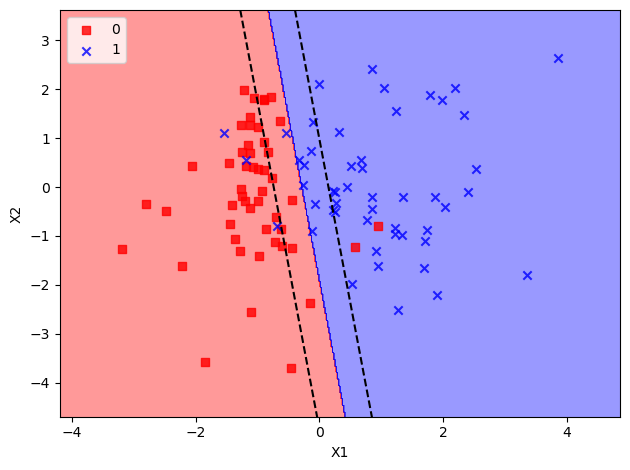

In [45]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                         weights=[0.5, 0.5], random_state=0)
clf = SVC(kernel='linear', random_state=0)
clf.fit(X, y)

w = clf.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-5, 5)
yy = a * xx - (clf.intercept_[0]) / w[1]
b = clf.support_vectors_[0]
yy_down = a * xx + (b[1] - a * b[0])
b = clf.support_vectors_[-1]
yy_up = a * xx + (b[1] - a * b[0])

plot_decision_regions(X, y, classifier=clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80, facecolors='none')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## k Nearest Neighbors (kNN)

kNN classifies by majority vote of **k** nearest neighbors.


### Listing 3-41. k Nearest Neighbor Model

**k-Nearest Neighbors (kNN)** classifies a point by majority vote among its k closest training examples. No explicit training phase — it memorizes the training set.

**Look for:** accuracy sensitive to k; k=1 often overfits, very large k underfits.

Train - Accuracy: 0.9714285714285714
Train - Confusion matrix: [[34  0  0]
 [ 0 31  1]
 [ 0  2 37]]
Train - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       0.94      0.97      0.95        32
           2       0.97      0.95      0.96        39

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105

Test - Accuracy: 0.9777777777777777
Test - Confusion matrix: [[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Test - classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98 

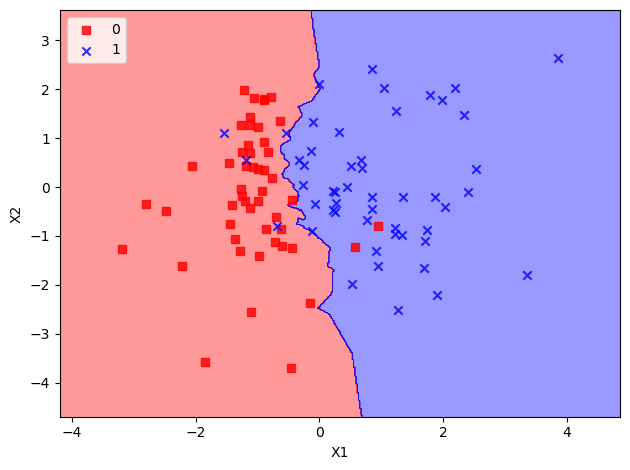

In [46]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

sc = preprocessing.StandardScaler()
X = sc.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
clf.fit(X_train, y_train)

print('Train - Accuracy:', metrics.accuracy_score(y_train, clf.predict(X_train)))
print('Train - Confusion matrix:', metrics.confusion_matrix(y_train, clf.predict(X_train)))
print('Train - classification report:', metrics.classification_report(y_train, clf.predict(X_train)))
print('Test - Accuracy:', metrics.accuracy_score(y_test, clf.predict(X_test)))
print('Test - Confusion matrix:', metrics.confusion_matrix(y_test, clf.predict(X_test)))
print('Test - classification report:', metrics.classification_report(y_test, clf.predict(X_test)))

X2, y2 = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           weights=[0.5, 0.5], random_state=0)
clf2 = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
clf2.fit(X2, y2)
plot_decision_regions(X2, y2, classifier=clf2)
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


---

## Time Series — ARIMA

ARIMA workflow: decompose → test stationarity → ACF/PACF → fit ARIMA(p,d,q) → evaluate.


### Listing 3-42. Decompose Time Series

**Time series decomposition** splits `TS.csv` into trend, seasonal, and residual components. Understanding these parts guides ARIMA model selection.

**Look for:** a clear upward trend and repeating seasonal pattern in the airline passenger data.

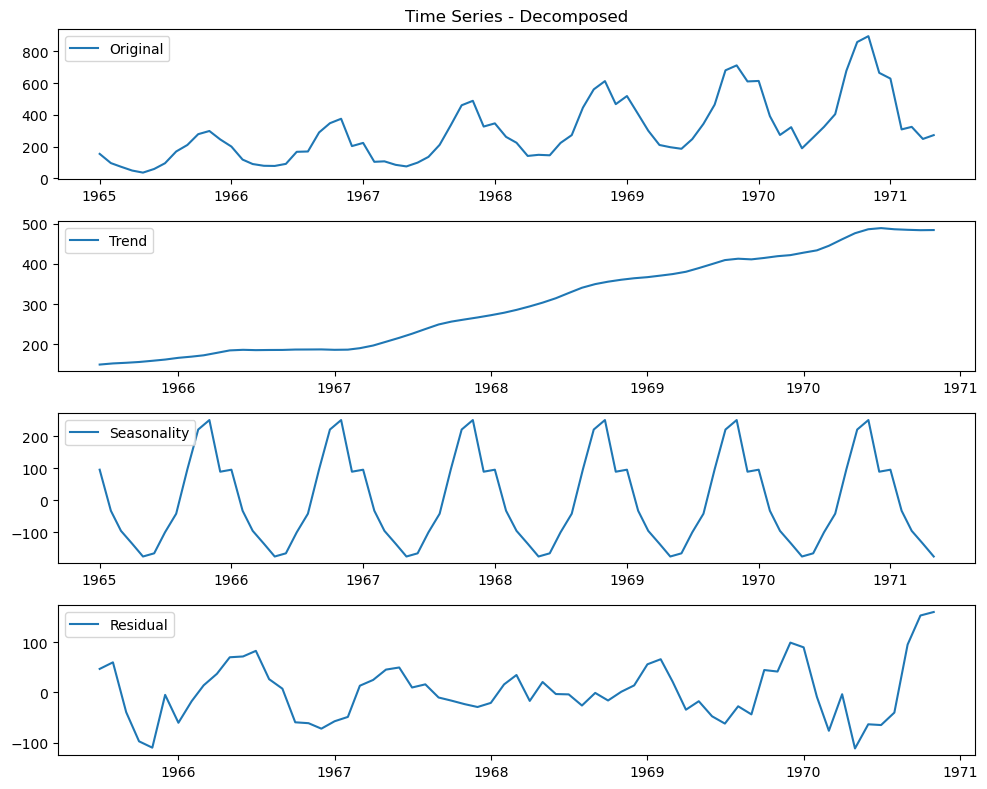

In [47]:
if not HAS_STATSMODELS:
    raise ImportError('Listings 3-42–3-48 require statsmodels')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

df_ts = pd.read_csv(str(DATA_DIR / 'TS.csv'))
ts = pd.Series(list(df_ts['Sales']), index=pd.to_datetime(df_ts['Month'], format='%Y-%m'))

decomposition = seasonal_decompose(ts)
fig, axes = plt.subplots(4, 1, figsize=(10, 8))
axes[0].plot(ts, label='Original'); axes[0].set_title('Time Series - Decomposed'); axes[0].legend()
axes[1].plot(decomposition.trend, label='Trend'); axes[1].legend()
axes[2].plot(decomposition.seasonal, label='Seasonality'); axes[2].legend()
axes[3].plot(decomposition.resid, label='Residual'); axes[3].legend()
plt.tight_layout()
plt.show()


### Listing 3-43. Check Stationary

ARIMA requires a **stationary** series (constant mean and variance). The **Augmented Dickey-Fuller (ADF)** test checks this — p-value < 0.05 means we reject non-stationarity.

**Look for:** raw series fails ADF; log-differenced series may pass.

p value > 0.05 means data is non-stationary: 0.9888894205170053
Log transform stationary check p value: 0.78531021248491
First order difference stationary check p value: 0.02402539283987643


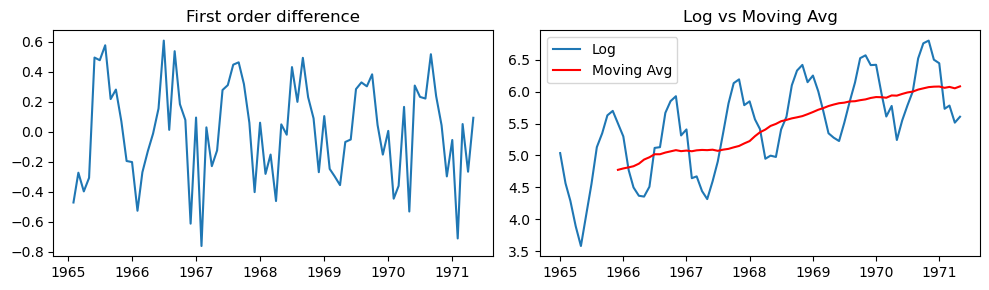

In [48]:
s_test = adfuller(ts, autolag='AIC')
print('p value > 0.05 means data is non-stationary:', s_test[1])

ts_log = np.log(ts).dropna()
print('Log transform stationary check p value:', adfuller(ts_log, autolag='AIC')[1])

ts_log_diff = (ts_log - ts_log.shift()).dropna()
print('First order difference stationary check p value:', adfuller(ts_log_diff, autolag='AIC')[1])

moving_avg = ts_log.rolling(12).mean()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.set_title('First order difference'); ax1.plot(ts_log_diff)
ax2.plot(ts_log, label='Log'); ax2.plot(moving_avg, color='red', label='Moving Avg')
ax2.set_title('Log vs Moving Avg'); ax2.legend()
plt.tight_layout()
plt.show()


### Listing 3-44. Check Autocorrelation

**ACF** (Autocorrelation Function) and **PACF** (Partial ACF) plots suggest ARIMA orders: how many AR (p) and MA (q) terms to include based on where correlations cut off.

**Look for:** significant spikes at early lags — hints for p and q in the ARIMA order.

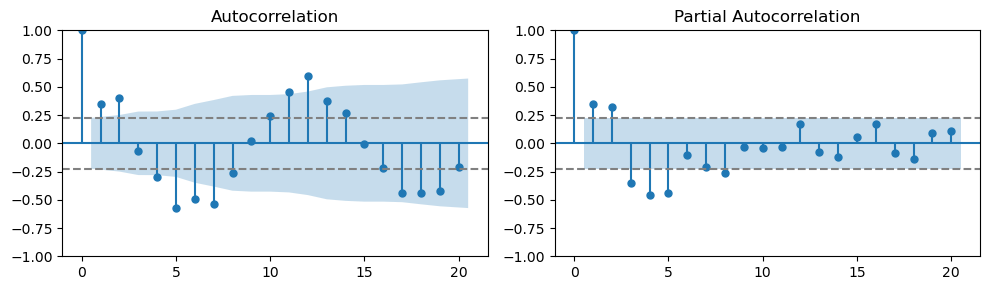

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
sm.graphics.tsa.plot_acf(ts_log_diff.values.squeeze(), lags=20, ax=ax1)
ax1.axhline(y=-1.96 / np.sqrt(len(ts_log_diff)), linestyle='--', color='gray')
ax1.axhline(y=1.96 / np.sqrt(len(ts_log_diff)), linestyle='--', color='gray')
sm.graphics.tsa.plot_pacf(ts_log_diff, lags=20, ax=ax2)
ax2.axhline(y=-1.96 / np.sqrt(len(ts_log_diff)), linestyle='--', color='gray')
ax2.axhline(y=1.96 / np.sqrt(len(ts_log_diff)), linestyle='--', color='gray')
plt.tight_layout()
plt.show()


### Listing 3-45. Build ARIMA Model and Evaluate

We fit **ARIMA(2, 0, 2)** on log-transformed passenger counts. AIC and BIC measure model quality (lower is better); Durbin-Watson checks residual autocorrelation.

**Look for:** fitted line tracking the historical trend; AIC/BIC values for comparison with other orders.

In [50]:
def fit_arima(endog, order):
    try:
        from statsmodels.tsa.arima.model import ARIMA
        return ARIMA(endog, order=order).fit()
    except (ImportError, AttributeError):
        return sm.tsa.ARIMA(endog, order=order).fit()

results_ARIMA = fit_arima(ts_log, (2, 0, 2))
ts_predict = results_ARIMA.predict()
print('AIC:', results_ARIMA.aic)
print('BIC:', results_ARIMA.bic)
print('MAE:', mean_absolute_error(ts_log.values, ts_predict.values))
print('RMSE:', np.sqrt(mean_squared_error(ts_log.values, ts_predict.values)))
print('Durbin-Watson:', sm.stats.durbin_watson(results_ARIMA.resid.values))


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


AIC: 7.852110626583533
BIC: 21.914943157705636
MAE: 0.19596526111240015
RMSE: 0.2397920770732497
Durbin-Watson: 1.8645734347908351


### Listing 3-46. Build ARIMA Model and Evaluate by Increasing p to 3

Increasing the AR order to **p = 3** may improve fit slightly — compare AIC/BIC to the previous model.

**Look for:** whether AIC drops enough to justify the extra complexity.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


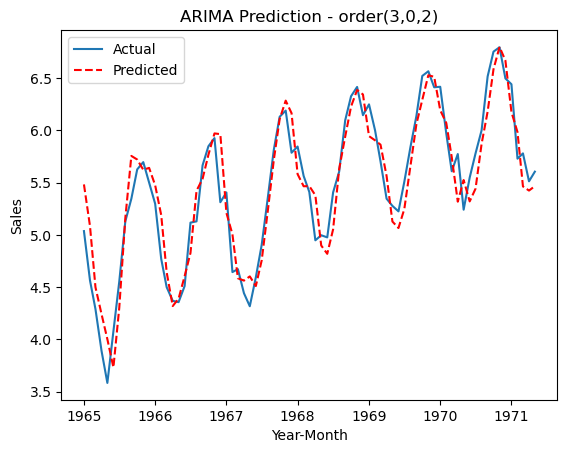

AIC: 9.693491754121457 BIC: 26.100129707097246


In [51]:
results_ARIMA = fit_arima(ts_log, (3, 0, 2))
ts_predict = results_ARIMA.predict()
plt.title('ARIMA Prediction - order(3,0,2)')
plt.plot(ts_log, label='Actual'); plt.plot(ts_predict, 'r--', label='Predicted')
plt.xlabel('Year-Month'); plt.ylabel('Sales'); plt.legend(loc='best'); plt.show()
print('AIC:', results_ARIMA.aic, 'BIC:', results_ARIMA.bic)


### Listing 3-47. ARIMA with First Order Differencing

Adding **d = 1** (first-order differencing) makes the series stationary by subtracting each value from the previous one.

**Look for:** AIC/BIC change and whether predictions improve on the validation period.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


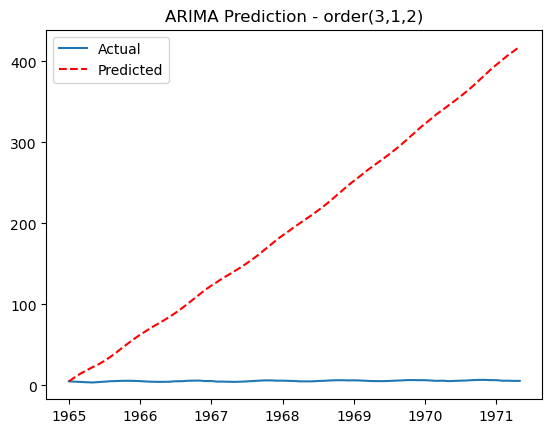

AIC: -33.21456074292026 BIC: -19.230160701202276


In [52]:
results_ARIMA = fit_arima(ts_log, (3, 1, 2))
ts_predict = results_ARIMA.predict()
pred_diff = pd.Series(ts_predict, copy=True).cumsum()
pred_log = pd.Series(ts_log.iloc[0], index=ts_log.index).add(pred_diff, fill_value=0)
plt.title('ARIMA Prediction - order(3,1,2)')
plt.plot(ts_log, label='Actual'); plt.plot(pred_log, 'r--', label='Predicted')
plt.legend(loc='best'); plt.show()
print('AIC:', results_ARIMA.aic, 'BIC:', results_ARIMA.bic)


### Listing 3-48. ARIMA Predict Function

`.predict(start, end)` forecasts **future months** beyond the training data — the practical payoff of time series modeling.

**Look for:** forecast extending past the last observed date on the plot.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


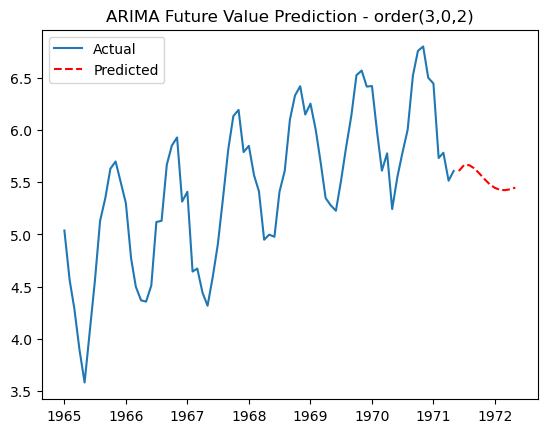

In [53]:
results_ARIMA = fit_arima(ts_log, (3, 0, 2))
ts_predict = results_ARIMA.predict('1971-06-01', '1972-05-01')
plt.title('ARIMA Future Value Prediction - order(3,0,2)')
plt.plot(ts_log, label='Actual'); plt.plot(ts_predict, 'r--', label='Predicted')
plt.legend(loc='best'); plt.show()


---

## Unsupervised Learning

Clustering and PCA find structure without labeled targets.


### Figure 3-18 — Unsupervised Learning Process Flow

Unsupervised learning has no target label: **load data → preprocess → choose k or components → fit clustering/PCA → interpret groups**. The goal is structure discovery, not prediction.

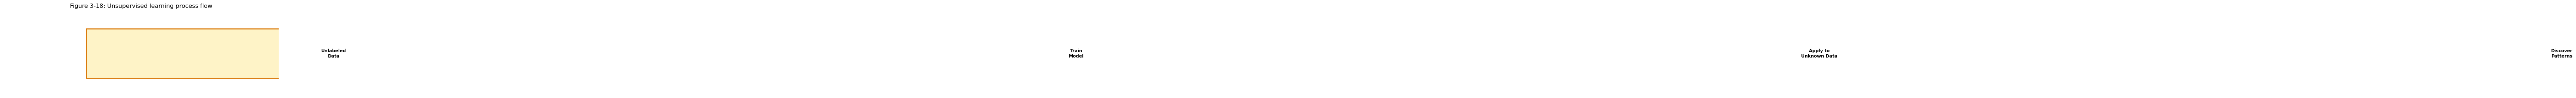

In [54]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
for i, (label, x) in enumerate([('Unlabeled\nData', 0.3), ('Train\nModel', 3.0),
                                  ('Apply to\nUnknown Data', 5.7), ('Discover\nPatterns', 8.4)]):
    ax.add_patch(plt.Rectangle((x, 0.2), 1.8, 0.6, fc='#fef3c7', ec='#d97706', lw=2))
    ax.text(x + 0.9, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')
for x in [2.1, 4.8, 7.5]:
    ax.annotate('', xy=(x + 0.5, 0.5), xytext=(x, 0.5), arrowprops=dict(arrowstyle='->', lw=2))
ax.set_title('Figure 3-18: Unsupervised learning process flow', fontsize=12, pad=10)
plt.tight_layout(); plt.show()


### k-means Concept Diagram


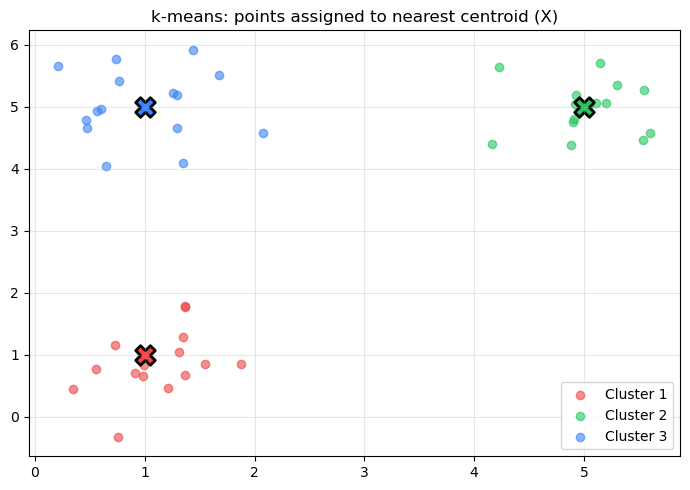

In [55]:
np.random.seed(11)
centroids = np.array([[1, 1], [5, 5], [1, 5]])
colors = ['#ef4444', '#22c55e', '#3b82f6']
fig, ax = plt.subplots(figsize=(7, 5))
for i, c in enumerate(centroids):
    pts = np.random.randn(15, 2) * 0.5 + c
    ax.scatter(pts[:, 0], pts[:, 1], c=colors[i], alpha=0.6, label=f'Cluster {i+1}')
    ax.scatter(c[0], c[1], c=colors[i], marker='X', s=200, edgecolors='black', linewidths=2)
ax.set_title('k-means: points assigned to nearest centroid (X)')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### Listing 3-49. k-means Clustering

**k-means clustering** groups Iris flowers into k clusters by minimizing within-cluster distance. We use petal length and width — two features that separate species well.

**Look for:** three clusters roughly matching the three Iris species.

In [56]:
from sklearn.cluster import KMeans

iris = datasets.load_iris()
iris_cl = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                       columns=iris['feature_names'] + ['species'])
iris_cl.columns = iris_cl.columns.str.replace(' ', '')
print(iris_cl.head())

X = iris_cl.iloc[:, :3].values
y = iris_cl['species'].values
X = preprocessing.StandardScaler().fit_transform(X)

model = KMeans(n_clusters=3, random_state=11)
model.fit(X)
print(model.labels_)


   sepallength(cm)  sepalwidth(cm)  petallength(cm)  petalwidth(cm)  species
0              5.1             3.5              1.4             0.2      0.0
1              4.9             3.0              1.4             0.2      0.0
2              4.7             3.2              1.3             0.2      0.0
3              4.6             3.1              1.5             0.2      0.0
4              5.0             3.6              1.4             0.2      0.0


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 2 0 0 0 0 0 0 0 0 1 1 1 2 1 2 1 2 1 2 2 2 2 2 2 1 2 2 2 2 1 2 2 2
 1 1 1 1 2 2 2 2 2 2 2 1 1 2 2 2 2 1 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 1 1 1 1 1 1 1 2 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]


### Listing 3-50. Accuracy of k-means Clustering

Since Iris has known species labels, we can measure clustering **accuracy** with `adjusted_rand_score` (1.0 = perfect match, 0 = random).

**Look for:** high adjusted Rand score when k=3.

Accuracy: 0.08666666666666667
Classification report:               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        50
         1.0       0.00      0.00      0.00        50
         2.0       0.27      0.26      0.26        50

    accuracy                           0.09       150
   macro avg       0.09      0.09      0.09       150
weighted avg       0.09      0.09      0.09       150



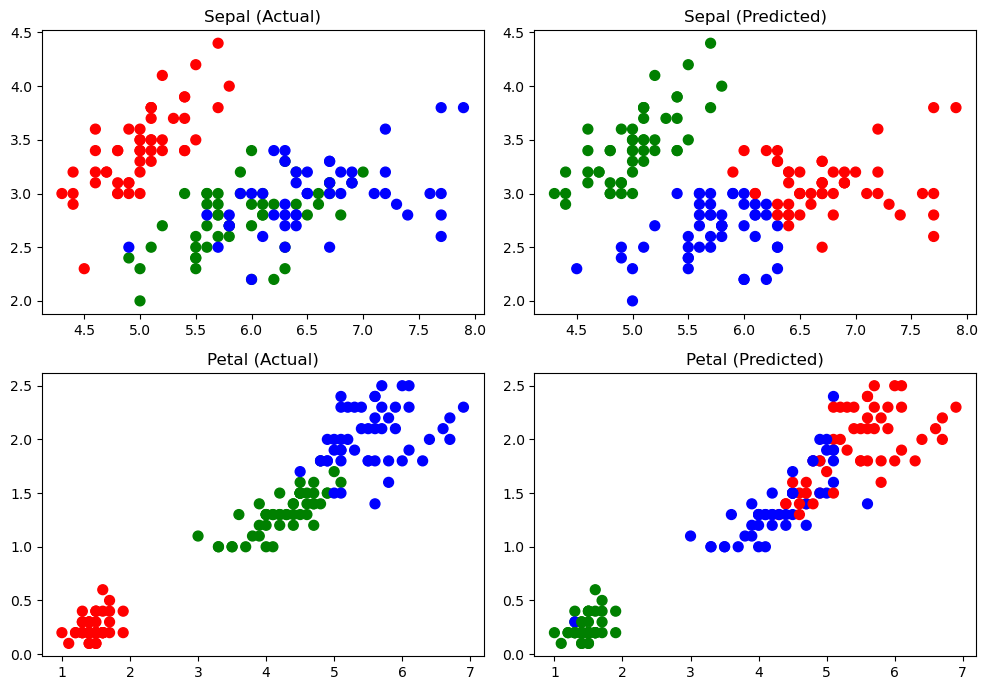

In [57]:
iris_cl['pred_species'] = np.choose(model.labels_, [1, 0, 2]).astype(np.int64)
print('Accuracy:', metrics.accuracy_score(y, iris_cl['pred_species']))
print('Classification report:', metrics.classification_report(y, iris_cl['pred_species']))

cmap = ListedColormap(['r', 'g', 'b'])
plt.figure(figsize=(10, 7))
for i, (xc, yc, ti) in enumerate([
    ('sepallength(cm)', 'sepalwidth(cm)', 'Sepal'),
    ('petallength(cm)', 'petalwidth(cm)', 'Petal')]):
    plt.subplot(2, 2, 2 * i + 1)
    plt.scatter(iris_cl[xc], iris_cl[yc], c=cmap(y.astype(int)), s=50)
    plt.title(f'{ti} (Actual)')
    plt.subplot(2, 2, 2 * i + 2)
    plt.scatter(iris_cl[xc], iris_cl[yc], c=cmap(iris_cl['pred_species']), s=50)
    plt.title(f'{ti} (Predicted)')
plt.tight_layout(); plt.show()


### Listing 3-51. Elbow Method

The **elbow method** plots within-cluster sum of squares (inertia) vs. k. The 'elbow' — where the curve bends — suggests a good k.

**Look for:** a bend around k=3 on Iris data.

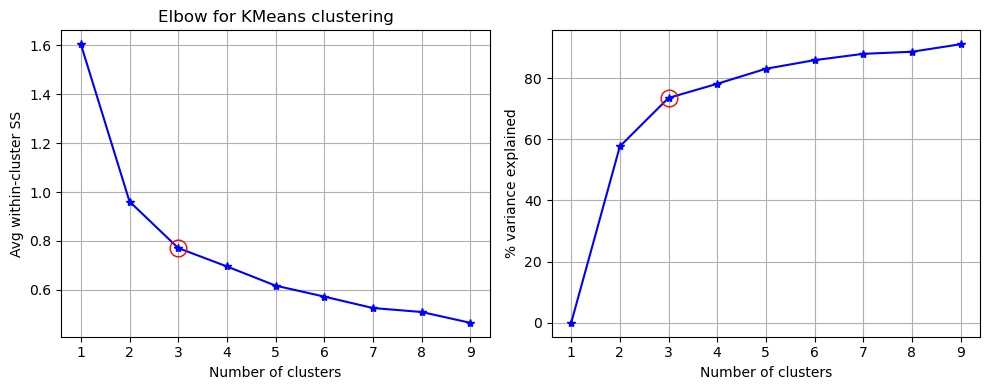

In [58]:
from scipy.spatial.distance import cdist, pdist

K = range(1, 10)
KM = [KMeans(n_clusters=k, random_state=11).fit(X) for k in K]
D_k = [cdist(X, k.cluster_centers_, 'euclidean') for k in KM]
dist = [np.min(D, axis=1) for D in D_k]
avgWithinSS = [sum(d) / X.shape[0] for d in dist]
wcss = [sum(d ** 2) for d in dist]
varExplained = (sum(pdist(X) ** 2) / X.shape[0] - wcss) / (sum(pdist(X) ** 2) / X.shape[0]) * 100
kIdx = 2
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(K, avgWithinSS, 'b*-')
plt.plot(K[kIdx], avgWithinSS[kIdx], marker='o', markersize=12, markeredgecolor='r', markerfacecolor='None')
plt.grid(True); plt.xlabel('Number of clusters'); plt.ylabel('Avg within-cluster SS')
plt.title('Elbow for KMeans clustering')
plt.subplot(1, 2, 2); plt.plot(K, varExplained, 'b*-')
plt.plot(K[kIdx], varExplained[kIdx], marker='o', markersize=12, markeredgecolor='r', markerfacecolor='None')
plt.grid(True); plt.xlabel('Number of clusters'); plt.ylabel('% variance explained')
plt.tight_layout(); plt.show()


### Listing 3-52. Silhouette Method

The **silhouette score** measures how similar each point is to its own cluster vs. other clusters (−1 to +1). We pick k with the highest average silhouette.

**Look for:** peak silhouette near k=3, confirming the elbow method.

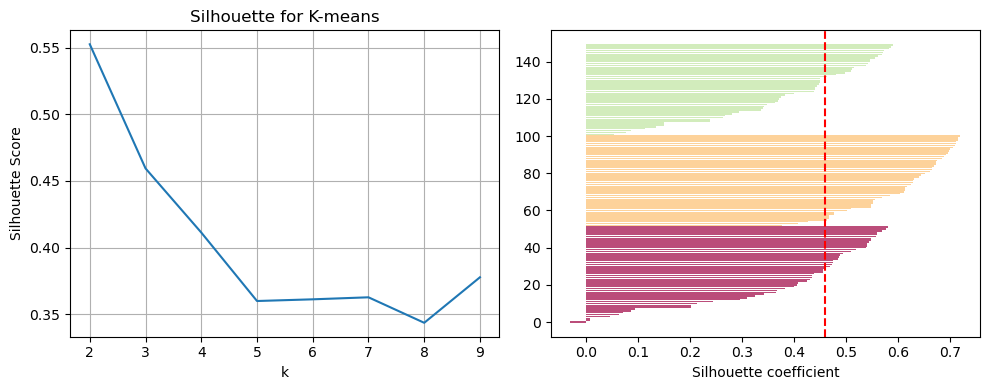

In [59]:
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm

score = [silhouette_score(X, KMeans(n_clusters=k, random_state=11).fit(X).labels_, metric='euclidean')
         for k in range(2, 10)]
model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=0).fit(X)
silhouette_vals = silhouette_samples(X, model.labels_)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(range(2, 10), score); plt.grid(True)
plt.ylabel('Silhouette Score'); plt.xlabel('k'); plt.title('Silhouette for K-means')
plt.subplot(1, 2, 2)
try:
    cmap = cm.get_cmap('Spectral')
except AttributeError:
    cmap = plt.colormaps['Spectral']
y_lower = 0
for i, c in enumerate(np.unique(model.labels_)):
    vals = np.sort(silhouette_vals[model.labels_ == c])
    y_upper = y_lower + len(vals)
    plt.barh(range(y_lower, y_upper), vals, facecolor=cmap(float(i) / 3), alpha=0.7)
    y_lower = y_upper
plt.axvline(x=np.mean(silhouette_vals), color='red', linestyle='--')
plt.xlabel('Silhouette coefficient'); plt.tight_layout(); plt.show()


### Hierarchical Clustering

Agglomerative clustering merges clusters bottom-up; visualize with a dendrogram.


### Listing 3-53. Hierarchical Clustering

**Agglomerative hierarchical clustering** merges the closest clusters bottom-up. Unlike k-means, you can inspect the merge history.

**Look for:** cluster labels assigned after cutting the tree at 3 groups.

In [60]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3)
model.fit(X)
print(model.labels_)
iris_cl['pred_species'] = model.labels_
print('Accuracy:', metrics.accuracy_score(y, iris_cl['pred_species']))
print('Classification report:', metrics.classification_report(y, iris_cl['pred_species']))


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 2 1 2 1 2 2
 1 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 1 2 2 2 1 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]
Accuracy: 0.7733333333333333
Classification report:               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        50
         1.0       0.64      0.74      0.69        50
         2.0       0.70      0.60      0.65        50

    accuracy                           0.77       150
   macro avg       0.78      0.77      0.77       150
weighted avg       0.78      0.77      0.77       150



### Listing 3-54. Hierarchical Clustering

A **dendrogram** visualizes the merge hierarchy — height shows dissimilarity at each merge. Cutting the tree horizontally at a chosen height gives a cluster count.

**Look for:** three main branches at a reasonable cut height.

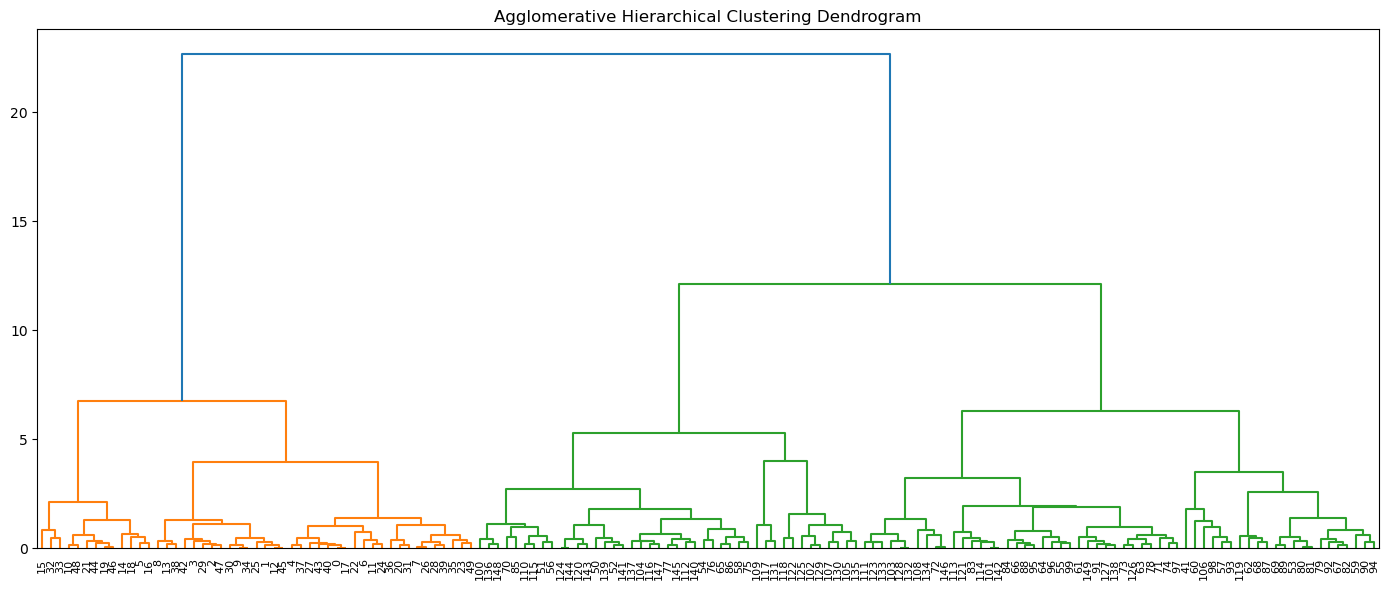

In [61]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist

Z = linkage(X, 'ward')
c, coph_dists = cophenet(Z, pdist(X))
plt.figure(figsize=(14, 6))
plt.title('Agglomerative Hierarchical Clustering Dendrogram')
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.tight_layout(); plt.show()


### Principal Component Analysis (PCA)

PCA reduces dimensionality while retaining maximum variance.


### Listing 3-55. Principal Component Analysis

**PCA (Principal Component Analysis)** finds new axes (components) that capture the most variance in the data. Useful for visualization and reducing dimensions before modeling.

**Look for:** first 2–3 components explaining most of the total variance.

Eigenvalues
 [2.93808505 0.9201649  0.14774182 0.02085386]
Cumulative Variance Explained [ 72.96244541  95.8132072   99.48212909 100.        ]


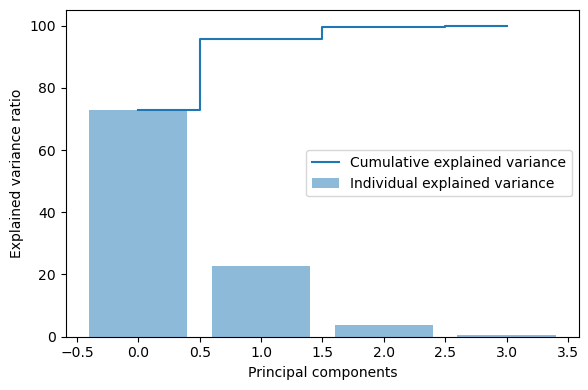

In [62]:
from sklearn.decomposition import PCA

iris = datasets.load_iris()
X_std = preprocessing.StandardScaler().fit_transform(iris.data)
eig_vals, eig_vecs = np.linalg.eig(np.cov(X_std.T))
print('Eigenvalues\n', eig_vals)
var_exp = [(i / sum(eig_vals)) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print('Cumulative Variance Explained', cum_var_exp)

plt.figure(figsize=(6, 4))
plt.bar(range(4), var_exp, alpha=0.5, label='Individual explained variance')
plt.step(range(4), cum_var_exp, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio'); plt.xlabel('Principal components')
plt.legend(loc='best'); plt.tight_layout(); plt.show()


### Listing 3-56. Visualize PCA

We project Iris onto the **first two principal components** and color by species — often the 2-D PCA plot shows clear separation without using original feature names.

**Look for:** three visually distinct groups in PC1–PC2 space.

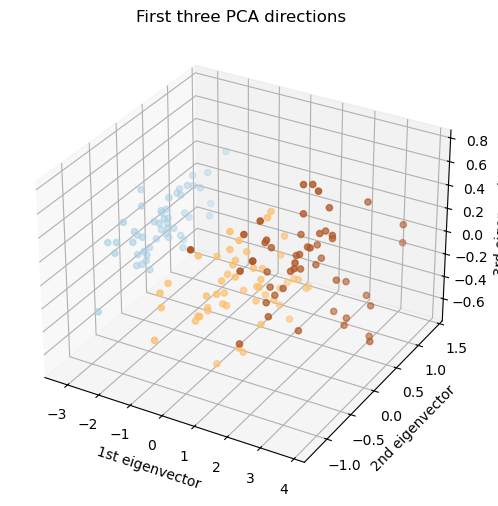

In [63]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
X_reduced = PCA(n_components=3).fit_transform(iris.data)
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2], c=iris.target, cmap=plt.cm.Paired)
ax.set_title('First three PCA directions')
ax.set_xlabel('1st eigenvector'); ax.set_ylabel('2nd eigenvector'); ax.set_zlabel('3rd eigenvector')
plt.show()


---

## Summary

In this chapter you learned feature engineering, EDA, supervised regression and classification, time-series ARIMA, and unsupervised clustering/PCA — all **56 listings** with modern Python 3 fixes.

## Additional Resources (Table 3-13)

| Resource | Description | Mode |
|---|---|---|
| [scikit-learn Documentation](https://scikit-learn.org/stable/user_guide.html) | ML algorithms | Online |
| [statsmodels Documentation](https://www.statsmodels.org/stable/index.html) | OLS, GLM, ARIMA | Online |
| [UCI Iris Dataset](https://archive.ics.uci.edu/ml/datasets/iris) | EDA & classification | Online |
| [Pandas Visualization](https://pandas.pydata.org/docs/user_guide/visualization.html) | DataFrame plots | Online |
| *Mastering ML with Python in Six Steps* Ch. 3 Code | Book companion notebooks | Book repo |

---

**Next:** Chapter 4 — Model Diagnosis and Tuning.
